# Custom Figure Generator for Papers
- Load multiple runtime instances and compare plots.
- Assuming usage of similar spectral configuration (same specConfigName)
- 

In [1]:
import glob
import os
from codec import CodecSystem, readPhotometry
# codec.py contains the CodecSystem class

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import pickle
from scipy.signal import savgol_filter

# make plotPaths in top directory
topDir = os.path.dirname(os.getcwd())
plotDir = os.path.join(topDir, 'paperPlots')
if not os.path.exists(plotDir):
    os.makedirs(plotDir)
print("Saving plots to ", plotDir)

# test = True
test = False

Saving plots to  /Users/nguyendat/Documents/GitHub/polarVortexJwst/paperPlots


### Helpers function

In [2]:
### Functions to read in spectra time series data ###
# default_specConfigName = '1200k_clouds=20'
default_specConfigName = '1200K_clouds=50'

def read_spec_codecs(photrunName, specConfigName=default_specConfigName):

    ### 1. Read in photometry results
    phot = readPhotometry(os.path.join(photometryh5dir, photrunName))

    ### 2. Read in spectra time series data + codec data
    runname = f'timeseries_{photrunName[:-3]}_{specConfigName}'
    dirPath = os.path.join(os.getcwd(), runname)

    # Search for files matching the pattern 'i=*.h5' in the directory
    spectra_files = sorted(glob.glob(os.path.join(dirPath, 'composite*.h5')))
    codec_files = sorted(glob.glob(os.path.join(dirPath, 'codec*.h5')))

    # Initialize the specs dictionary
    specs = {}
    codecs = {}

    # Iterate through each inclination file and load spectra
    for index, file in enumerate(spectra_files):
        inclin = os.path.basename(file).split('=')[1].split('.')[0]  # Extract 'i' value from the filename

        specs[inclin] = CodecSystem.load_spectra_ts_h5(file)
        codecs[inclin] = CodecSystem.load_codec_images_h5(codec_files[index])

    ### 3. Load codec configuration
    configPath = glob.glob(os.path.join(dirPath, 'codec_config.json'))[0]
    codec_loaded = CodecSystem()
    codec_loaded.import_mapping(configPath, validate_files=False)
    
    return phot, specs, codecs, codec_loaded

### Load in PICASO spectra: n=50 runs

- All photometry runs in this notebook should use the same PICASO spectra config n=50 (hence same fsed, wavelength region, cloud setup, etc. everything spectral related).

In [3]:

### Load the full picaso result summary: The simple fsed model
# Search for .csv files in the specified directory
dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/'
# specFolderName = 'bd_grid_20251108_162457_all5condensates'
# specFolderName = 'bd_grid_20251202_simple3clouds'
# specFolderName = 'bd_grid_noCH4_20251209_153457'
specFolderName = 'bd_grid_noCH4_n=50_20260322_193125'

specpath = os.path.join(dir, specFolderName)
specSummary = pickle.load(open(os.path.join(specpath, 'results_summary.pkl'), 'rb'))

modelID_list = [picasomodelfile['model_id'] for picasomodelfile in specSummary]
print(f"\nFound {len(modelID_list)} model IDs in the summary:")
print(modelID_list)
print("\nSample params file: ")
print(specSummary[0]['params'])

# fsed_list
fsed_list = []
# Loop through all codec_id and get fsed
for picasomodelfile in specSummary:
    fsed = picasomodelfile['params'].get('fsed', None)
    modelid = picasomodelfile['model_id']
    fsed_list.append((modelid, fsed))


Found 50 model IDs in the summary:
['bd_1200_10000_1.0000E+07_1.0000_cloudy', 'bd_1200_10000_1.0000E+07_1.0040_cloudy', 'bd_1200_10000_1.0000E+07_1.0080_cloudy', 'bd_1200_10000_1.0000E+07_1.0120_cloudy', 'bd_1200_10000_1.0000E+07_1.0160_cloudy', 'bd_1200_10000_1.0000E+07_1.0200_cloudy', 'bd_1200_10000_1.0000E+07_1.0240_cloudy', 'bd_1200_10000_1.0000E+07_1.0280_cloudy', 'bd_1200_10000_1.0000E+07_1.0320_cloudy', 'bd_1200_10000_1.0000E+07_1.0360_cloudy', 'bd_1200_10000_1.0000E+07_1.0400_cloudy', 'bd_1200_10000_1.0000E+07_1.0440_cloudy', 'bd_1200_10000_1.0000E+07_1.0480_cloudy', 'bd_1200_10000_1.0000E+07_1.0520_cloudy', 'bd_1200_10000_1.0000E+07_1.0560_cloudy', 'bd_1200_10000_1.0000E+07_1.0600_cloudy', 'bd_1200_10000_1.0000E+07_1.0640_cloudy', 'bd_1200_10000_1.0000E+07_1.0680_cloudy', 'bd_1200_10000_1.0000E+07_1.0720_cloudy', 'bd_1200_10000_1.0000E+07_1.0760_cloudy', 'bd_1200_10000_1.0000E+07_1.0800_cloudy', 'bd_1200_10000_1.0000E+07_1.0840_cloudy', 'bd_1200_10000_1.0000E+07_1.0880_cloudy

In [4]:
### Load the full picaso result summary: The complex fsed model
# Search for .csv files in the specified directory
dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/'
specFolderName2 = 'bd_grid_noCH4_complex_fsed_test_fe[14]_mgsiO3[3.1-3.9]_na2s[4.6-2.8]_20260321_143742'

specpath2 = os.path.join(dir, specFolderName2)
specSummary2 = pickle.load(open(os.path.join(specpath2, 'results_summary.pkl'), 'rb'))

modelID_list2 = [picasomodelfile2['model_id'] for picasomodelfile2 in specSummary2]
print(f"\nFound {len(modelID_list2)} model IDs in the summary:")
print(modelID_list2)
print("\nSample params file: ")
print(specSummary2[0]['params'])

# fsed_list
fsed_list2 = []
# Loop through all codec_id and get fsed
for picasomodelfile2 in specSummary2:
    fsed = picasomodelfile2['params'].get('fsed', None)
    modelid = picasomodelfile['model_id']
    fsed_list2.append((modelid, fsed))


Found 20 model IDs in the summary:
['bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.10-Na2S4.60_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.14-Na2S4.51_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.18-Na2S4.41_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.23-Na2S4.32_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.27-Na2S4.22_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.31-Na2S4.13_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.35-Na2S4.03_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.39-Na2S3.94_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.44-Na2S3.84_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.48-Na2S3.75_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.52-Na2S3.65_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.56-Na2S3.56_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.61-Na2S3.46_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.65-Na2S3.37_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.69-Na2S3.27_cloudy', 'bd_1200_10000_1.0E+07_Fe14.00-MgSiO33.73-Na2S3.18_cloudy', 'bd

### Read in photometry files for 

- type `ts`: Test Static (60hr baseline), number: `empty`, `1`, `2`
- type `td`: Test Dynamic (60hr baseline), number: `empty`, `1`, `2`
- type `js`: JWSR Static (180hr baseline)

In [6]:

### Read the photometry file
photometryh5dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/'

### Test-dataset: 

# 60 hours baseline, static pole: Test Static (ts)
photrunName_ts = 'test_polar_v0_static.h5'
phot_ts, specs_ts, codecs_ts, codec_loaded_ts = read_spec_codecs(photrunName_ts) 
time_ts = phot_ts['0']['time_array'] # load the time indices 

photrunName_ts1 = 'test_polar_v1_static.h5'
phot_ts1, specs_ts1, codecs_ts1, codec_loaded_ts1 = read_spec_codecs(photrunName_ts1) 
time_ts1 = phot_ts1['0']['time_array'] # load the time indices

photrunName_ts2 = 'test_polar_v2_static.h5'
phot_ts2, specs_ts2, codecs_ts2, codec_loaded_ts2 = read_spec_codecs(photrunName_ts2) 
time_ts2 = phot_ts2['0']['time_array'] # load the time indices

# 60 hours baseline, dynamic pole: Test Dynamic (td)
photrunName_td = 'test_polar_v0_dynamic.h5'
phot_td, specs_td, codecs_td, codec_loaded_td = read_spec_codecs(photrunName_td) 
time_td = phot_td['0']['time_array'] # load the time indices 

photrunName_td1 = 'test_polar_v1_dynamic.h5'
phot_td1, specs_td1, codecs_td1, codec_loaded_td1 = read_spec_codecs(photrunName_td1) 
time_td1 = phot_td1['0']['time_array'] # load the time indices  

photrunName_td2 = 'test_polar_v2_dynamic.h5'
phot_td2, specs_td2, codecs_td2, codec_loaded_td2 = read_spec_codecs(photrunName_td2) 
time_td2 = phot_td2['0']['time_array'] # load the time indices

### JWST-data: 

# multiepoch, static pole: JWST Static (js)
photrunName_js = 'jwst_v0_static.h5'
phot_js, specs_js, codecs_js, codec_loaded_js = read_spec_codecs(photrunName_js)
time_js = phot_js['0']['time_array'] # load the time indices

Added codec 'cloud_thickness' with 50 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Generated 50 codec combinations
ID range: 0-49
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v0_static_1200K_clouds=50/codec_config.json
  Codec combinations: 50
  Spectra assignments: 50
Added codec 'cloud_thickness' with 50 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Generated 50 codec combinations
ID range: 0-49
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v1_static_1200K_clouds=50/codec_config.json
  Codec combinations: 50
  Spectra assignments: 50
Added codec 'cloud_t

IndexError: list index out of range

In [ ]:
print(  phot_ts['90']['gray_array'].shape,
        phot_td['90']['gray_array'].shape,
        phot_js['90']['gray_array'].shape)
# temp fix: recreate time_js correctly by concatenating time_ts three times, with gap of 60 in between
time_js_corrected = np.concatenate([time_ts, time_ts + 60, time_ts + 120])
print("Corrected time_js shape: ", time_js_corrected.shape)


(120, 300, 300) (120, 300, 300) (360, 300, 300)
Corrected time_js shape:  (360,)


In [7]:
### Somes helpful metadata
# codec length
n = len(codec_loaded_ts.spectra_assignments.keys())

# how to load a spectrum
if test:
    wave, flux = codec_loaded_ts.load_spectrum(codec_id=0)
    print('### Spectral assignment keys ###: \n', codec_loaded_ts.spectra_assignments.keys())
    print('### Range of wavelength values ###: \n', wave[::50])
    print('### Corresponding flux ###: \n', flux[::50])


### Read in codecs of complex_fsed spectra

In [75]:

# 60 hours baseline, static pole, complex Fsed (fsedts)
photrunName_fsedts = 'test_polar_v0_static.h5'
complexFsed_specConfigName = '1200K_complexFsed_Fe14_Si3_Na4'

phot_fsedts, specs_fsedts, codecs_fsedts, codec_loaded_fsedts = read_spec_codecs(photrunName_fsedts,
                                                                specConfigName=complexFsed_specConfigName) 
time_fsedts = phot_fsedts['0']['time_array'] # load the time indices 

Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v0_static_1200K_complexFsed_Fe14_Si3_Na4/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20


### [Figure] Spectral-codec image + all Picaso spectra | type `ts2`

{'0': 1.1584439623143268e-05, '1': 0.019266047746204357, '3': 0.007518911689569151, '4': 0.006320238355497428, '5': 0.00599061460559037, '6': 0.009687600659228239, '8': 0.00046900317884852145, '9': 0.005019527287069663, '10': 0.004872961304910676, '12': 0.004733530873551225, '13': 0.004872327202283145, '14': 0.004796233199051615, '15': 0.004742743767901433, '17': 0.008813360031932166, '18': 0.00022348727693499165, '19': 0.004814383619684796, '21': 0.004924085603933121, '22': 0.004305116331364391, '23': 0.004796207847632208, '24': 0.005683345831756767, '26': 0.6984914322183974, '27': 0.13821503094995116, '28': 0.0041279581885298325, '29': 0.005618652741714734, '31': 0.000511676541306218, '32': 0.002569808622711873, '33': 0.0025109327299862524, '35': 0.002390252068758489, '36': 0.002114262879872941, '37': 0.0019911850026422106, '38': 0.00172520611664047, '40': 0.0016414737954629209, '41': 0.0017510767071032402, '42': 0.016689602952411085, '44': 0.0016308617412278846, '45': 0.001277685957

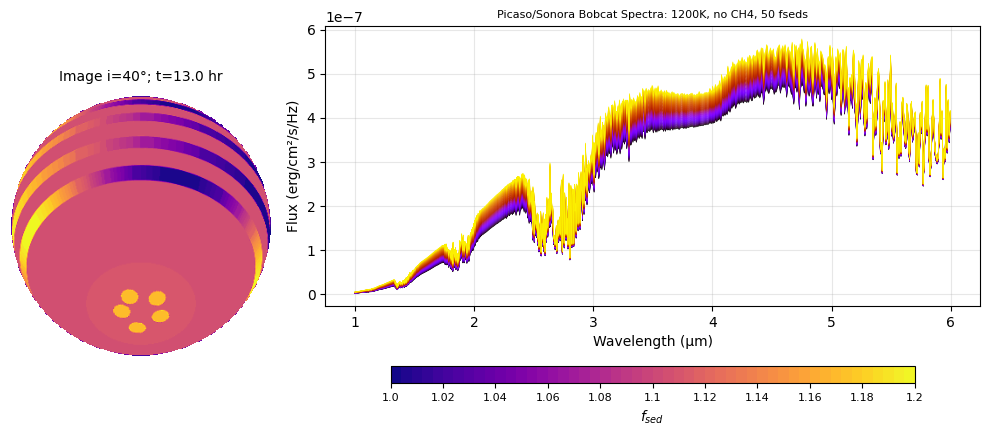

In [27]:
# ===== Plot all codecs spectra with an example image =====

save = False
# save = True

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), width_ratios=[1.2, 3])
codename = photrunName_ts2 + '-' + default_specConfigName
if test: fig.suptitle(codename, fontsize=6)

ax = axes[0]
frame_id = 26
ax.imshow(codecs_ts2['40'][frame_id]['composite'], cmap='plasma')
ax.set_title(f'Image i=40°; t={frame_id/2} hr', fontsize=10, pad=10)
print(codecs_ts2['40'][frame_id]['fractions']['fractions'])
ax.set_xticks([]), ax.set_yticks([])
for spines in ax.spines.values():
    spines.set_visible(False)

# ===== Plot 1: All individual spectra =====
ax = axes[1]
for codec_id in range(n):  # Plot all codec
    wave_i, flux_i = codec_loaded_ts2.load_spectrum(codec_id)
    ax.plot(wave_i, flux_i, alpha=1, lw=0.5, color=plt.cm.gnuplot(codec_id / n))
    ax.plot([], [], lw=2, color=plt.cm.gnuplot(codec_id / n), 
            label=r'$f_{sed}$='+f'{fsed_list[codec_id][1]}')  # For legend

ax.set_xlabel('Wavelength (μm)', fontsize=10)
ax.set_ylabel('Flux (erg/cm²/s/Hz)', fontsize=10)
ax.set_title('Picaso/Sonora Bobcat Spectra: 1200K, no CH4, 50 fseds', fontsize=8)
# # Move legend above plot with multiple columns
# ax.legend(fontsize=8, bbox_to_anchor=(0.5, 1.25), loc='center', ncol=7, 
#           frameon=False, columnspacing=1.0)

# Create discrete colorbar instead of continuous
bounds = np.linspace(1.0, 1.2, num=51)
sm = plt.cm.ScalarMappable(cmap='plasma', 
                           norm=plt.Normalize(vmin=1.0, vmax=1.2))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.15, 
                    aspect=30, shrink=0.8, boundaries=bounds, ticks=bounds)
cbar.set_label(r'$f_{sed}$', fontsize=10)
cbar.ax.set_xticks(np.linspace(1.0, 1.2, num=11))
cbar.ax.set_xticklabels([1.0, 1.02, 1.04, 1.06, 1.08, 1.1, 1.12, 1.14, 1.16, 1.18, 1.2], fontsize=8)

ax.set_yscale('linear')
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.subplots_adjust(hspace=20)
handle = f'all_codecs_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

### [Figure]: Similar but using complex-fsed spectra | type `fsedts`

{'0': 1.1644933145322674e-05, '1': 0.00021192219187950493, '2': 0.0005403032798216325, '3': 0.0010824958807084165, '4': 0.0016475377034272287, '5': 0.0023991814783791967, '6': 0.003133592867937558, '7': 0.003881586042265547, '8': 0.004800037684864585, '9': 0.0060571285310337475, '10': 0.7742681978229501, '11': 0.1406052632468505, '12': 0.007200961204738145, '13': 0.006915931838169951, '14': 0.006897649465950096, '15': 0.0064037191172889125, '16': 0.005905671056640734, '17': 0.020323641297521868, '18': 0.0043732765961391785, '19': 0.003340257760288012}


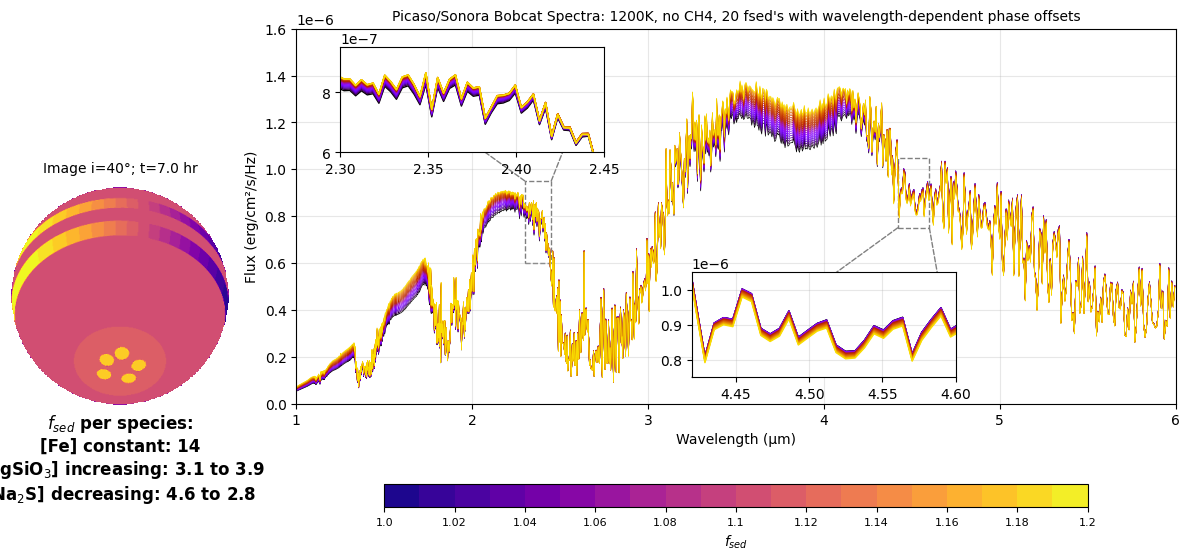

In [ ]:
# ===== Plot all codecs spectra with an example image =====

save = False
# save = True

fig, axes = plt.subplots(1, 2, figsize=(12, 6), width_ratios=[1, 4])
codename = photrunName_td + '-' + complexFsed_specConfigName
if test: fig.suptitle(codename, fontsize=6)

ax = axes[0]
frame_id = 14
ax.imshow(codecs_fsedts['40'][frame_id]['composite'], cmap='plasma')
ax.set_title(f'Image i=40°; t={frame_id/2} hr', fontsize=10, pad=10)
print(codecs_fsedts['40'][frame_id]['fractions']['fractions'])
ax.set_xticks([]), ax.set_yticks([])
for spines in ax.spines.values():
    spines.set_visible(False)

# add text outside the plot
ax.set_xlabel(r'$f_{sed}$ per species:' + '\n' + \
              r'[Fe] constant: 14' + '\n' + \
              r'[MgSiO$_3$] increasing: 3.1 to 3.9' + '\n' + \
              r'[Na$_2$S] decreasing: 4.6 to 2.8', 
                weight='bold', fontsize=12)

# ===== Plot 1: All individual spectra =====
ax = axes[1]
ncodec = 20

# Create inset plot zoomed in to wavelength region from 2.1 to 2.3um
ax_inset = ax.inset_axes([0.05, 0.67, 0.3, 0.28])

# Second inset plot zoomed in to region from 2.8 to 3.0um
ax_inset2 = ax.inset_axes([0.45, 0.07, 0.3, 0.28])

for codec_id in range(ncodec):  # Plot all codec
    wave_i, flux_i = codec_loaded_fsedts.load_spectrum(codec_id)
    ax.plot(wave_i, flux_i, alpha=1, lw=0.5, color=plt.cm.gnuplot(codec_id / ncodec))
    ax.plot([], [], lw=2, color=plt.cm.gnuplot(codec_id / ncodec), 
            # label=r'$f_{sed}$='+f'{fsed_list[codec_id][1]}')  # For legend
            label='')

    # inset plots:
    ax_inset.plot(wave_i, flux_i, alpha=1, lw=1, color=plt.cm.gnuplot(codec_id / ncodec))
    ax_inset2.plot(wave_i, flux_i, alpha=1, lw=1, color=plt.cm.gnuplot(codec_id / ncodec))

ax.set_xlabel('Wavelength (μm)', fontsize=10)
ax.set_ylabel('Flux (erg/cm²/s/Hz)', fontsize=10)
ax.set_title('Picaso/Sonora Bobcat Spectra: 1200K, no CH4, 20 fsed\'s with wavelength-dependent phase offsets', fontsize=10)
# # Move legend above plot with multiple columns
# ax.legend(fontsize=8, bbox_to_anchor=(0.5, 1.25), loc='center', ncol=7, 
#           frameon=False, columnspacing=1.0)

# Set inset plot limits and labels
ax_inset.set_xlim(2.3, 2.45)
ax_inset.set_ylim(0.6e-6, 0.95e-6)
ax_inset.grid(True, alpha=0.3)

ax_inset2.set_xlim(4.42, 4.6)
ax_inset2.set_ylim(0.75e-6, 1.05e-6)
ax_inset2.grid(True, alpha=0.3)

### Draw boxes on the main plot to show where the insets are zooming in
from matplotlib.patches import Rectangle
# Box for first inset
rect1 = Rectangle((2.3, 0.6e-6), 0.15, 0.35e-6, linewidth=1, edgecolor='gray', facecolor='none', linestyle='--')
ax.add_patch(rect1)
# Box for second inset
rect2 = Rectangle((4.42, 0.75e-6), 0.18, 0.3e-6, linewidth=1, edgecolor='gray', facecolor='none', linestyle='--')
ax.add_patch(rect2)

### Draw 2 lines connecting the boxes for each insets
from matplotlib.patches import ConnectionPatch
# For first inset
con1 = ConnectionPatch(xyA=(2.3, 0.95e-6), xyB=(0, 1), coordsA='data', coordsB='axes fraction', axesB=ax_inset, color='gray', linestyle='--')
ax.add_artist(con1)
con2 = ConnectionPatch(xyA=(2.45, 0.95e-6), xyB=(1, 1), coordsA='data', coordsB='axes fraction', axesB=ax_inset, color='gray', linestyle='--')
ax.add_artist(con2)
# For second inset
con3 = ConnectionPatch(xyA=(4.42, 0.75e-6), xyB=(0, 0), coordsA='data', coordsB='axes fraction', axesB=ax_inset2, color='gray', linestyle='--')
ax.add_artist(con3)
con4 = ConnectionPatch(xyA=(4.6, 0.75e-6), xyB=(1, 0), coordsA='data', coordsB='axes fraction', axesB=ax_inset2, color='gray', linestyle='--')
ax.add_artist(con4)


# Create discrete colorbar instead of continuous
bounds = np.linspace(1.0, 1.2, num=21)
sm = plt.cm.ScalarMappable(cmap='plasma', 
                           norm=plt.Normalize(vmin=1.0, vmax=1.2))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.15, 
                    aspect=30, shrink=0.8, boundaries=bounds, ticks=bounds)
cbar.set_label(r'$f_{sed}$', fontsize=10)
cbar.ax.set_xticks(np.linspace(1.0, 1.2, num=11))
cbar.ax.set_xticklabels([])
cbar.ax.set_xticklabels([1.0, 1.02, 1.04, 1.06, 1.08, 1.1, 1.12, 1.14, 1.16, 1.18, 1.2], fontsize=8)

ax.set_yscale('linear')
ax.grid(True, alpha=0.3)
ax.set_xlim(1,6)
ax.set_ylim(0, 1.6e-6)

plt.tight_layout()
# plt.subplots_adjust(hspace=20)
handle = f'all_complexFsed_codecs_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

### [Figure]: Timeseries of atmo images at two inclination | type `td`

/var/folders/n_/ynkgs9fs2ts72fkcb79xcjlh0000gn/T/ipykernel_5412/2119392430.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


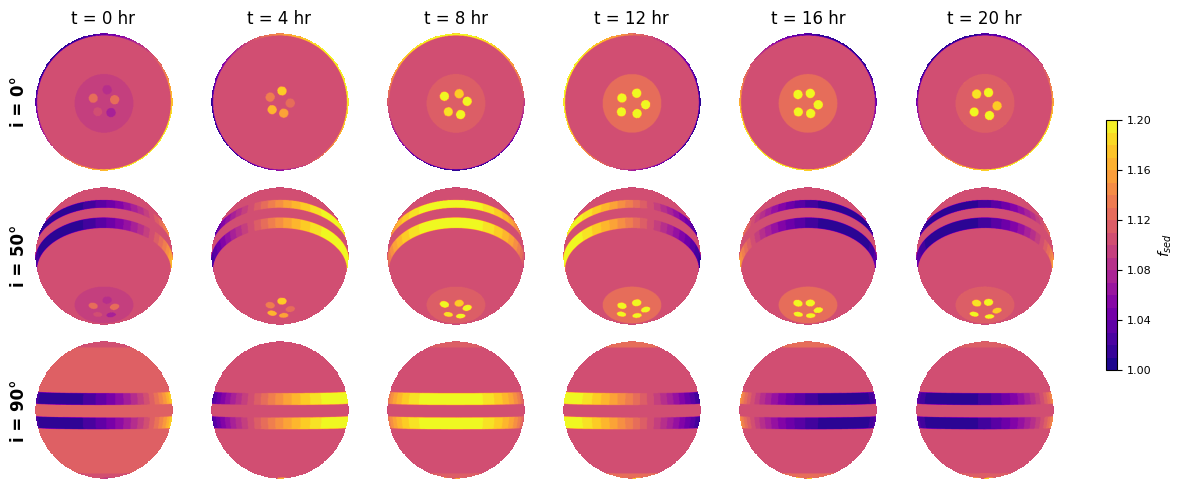

In [42]:
# Plot 2 rows of atmosphere image at two inclinations, each columns at different time
save = True
# save = False
codename = photrunName_td + '-' + default_specConfigName

# fig, axes = plt.subplots(2, 6, figsize=(10, 4))
fig, axes = plt.subplots(3, 6, figsize=(11, 5))

if test: fig.suptitle(codename, fontsize=6)

time_indices = [i*8 for i in range(6)]  # select time indices
shift =[0, 0, 0]

# for i, inclin in enumerate(['30', '70']):
for i, inclin in enumerate(['0', '50', '90']):
    for j, t_idx in enumerate(time_indices):
        t_idx += shift[i]
        ax = axes[i, j]
        ax.imshow(codecs_td[inclin][t_idx]['composite'], cmap='plasma')
        ax.set_xticks([])
        ax.set_yticks([])
        if i==0: ax.set_title(f't = {time_td[t_idx]:.0f} hr')
        if j==0: ax.set_ylabel(f'i = {inclin}°', fontsize=12, weight='bold')
        for spine in ax.spines.values():
            spine.set_visible(False)

## add a vertical colorbar
cbar_ax = fig.add_axes([1.02, 0.25, 0.01, 0.5])  # [left, bottom, width, height]
bounds = np.linspace(1.0, 1.2, num=21)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=1.0, vmax=1.2))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, boundaries=bounds, ticks=bounds)
cbar.set_label(r'$f_{sed}$', fontsize=10)
cbar.ax.set_yticks(np.linspace(1.0, 1.2, num=6))
cbar.ax.set_yticklabels([f'{x:.2f}' for x in np.linspace(1.0, 1.2, num=6)], fontsize=8)

# # Create discrete colorbar instead of continuous
# bounds = np.linspace(1.0, 1.2, num=21)
# sm = plt.cm.ScalarMappable(cmap='plasma', 
#                            norm=plt.Normalize(vmin=1.0, vmax=1.2))
# sm.set_array([])
# cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.15, 
#                     aspect=30, shrink=0.8, boundaries=bounds, ticks=bounds)
# cbar.set_label(r'$f_{sed}$', fontsize=10)
# cbar.ax.set_xticks(np.linspace(1.0, 1.2, num=11))
# cbar.ax.set_xticklabels([1.0, 1.02, 1.04, 1.06, 1.08, 1.1, 1.12, 1.14, 1.16, 1.18, 1.2], fontsize=8)

plt.tight_layout()
handle = f'atmo_images_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

### [Figure]: Timeseries of atmo images at two inclination | type `td1`

/var/folders/n_/ynkgs9fs2ts72fkcb79xcjlh0000gn/T/ipykernel_90681/1764074444.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


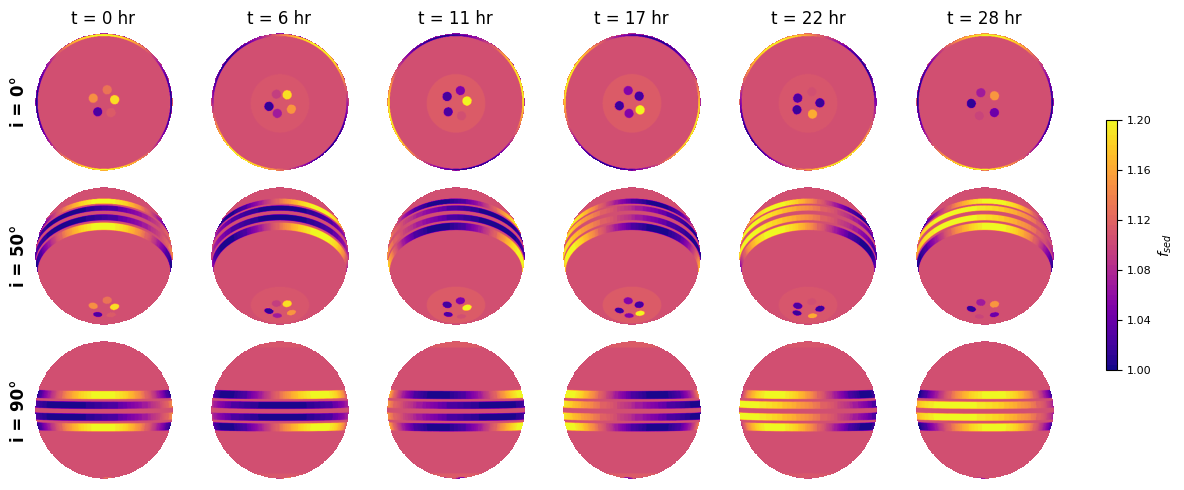

In [72]:
# Plot 2 rows of atmosphere image at two inclinations, each columns at different time
# save = True
save = False
codename = photrunName_td1 + '-' + default_specConfigName

# fig, axes = plt.subplots(2, 6, figsize=(10, 4))
fig, axes = plt.subplots(3, 6, figsize=(11, 5))

if test: fig.suptitle(codename, fontsize=6)

time_indices = [i*22 for i in range(6)]  # select time indices
shift =[0, 0, 0]

# for i, inclin in enumerate(['30', '70']):
for i, inclin in enumerate(['0', '50', '90']):
    for j, t_idx in enumerate(time_indices):
        t_idx += shift[i]
        ax = axes[i, j]
        ax.imshow(codecs_td1[inclin][t_idx]['composite'], cmap='plasma')
        ax.set_xticks([])
        ax.set_yticks([])
        if i==0: ax.set_title(f't = {time_td1[t_idx]:.0f} hr')
        if j==0: ax.set_ylabel(f'i = {inclin}°', fontsize=12, weight='bold')
        for spine in ax.spines.values():
            spine.set_visible(False)

## add a vertical colorbar
cbar_ax = fig.add_axes([1.02, 0.25, 0.01, 0.5])  # [left, bottom, width, height]
bounds = np.linspace(1.0, 1.2, num=51)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=1.0, vmax=1.2))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, boundaries=bounds, ticks=bounds)
cbar.set_label(r'$f_{sed}$', fontsize=10)
cbar.ax.set_yticks(np.linspace(1.0, 1.2, num=6))
cbar.ax.set_yticklabels([f'{x:.2f}' for x in np.linspace(1.0, 1.2, num=6)], fontsize=8)

# # Create discrete colorbar instead of continuous
# bounds = np.linspace(1.0, 1.2, num=21)
# sm = plt.cm.ScalarMappable(cmap='plasma', 
#                            norm=plt.Normalize(vmin=1.0, vmax=1.2))
# sm.set_array([])
# cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.15, 
#                     aspect=30, shrink=0.8, boundaries=bounds, ticks=bounds)
# cbar.set_label(r'$f_{sed}$', fontsize=10)
# cbar.ax.set_xticks(np.linspace(1.0, 1.2, num=11))
# cbar.ax.set_xticklabels([1.0, 1.02, 1.04, 1.06, 1.08, 1.1, 1.12, 1.14, 1.16, 1.18, 1.2], fontsize=8)

plt.tight_layout()
handle = f'atmo_images_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

### [Figure]: Timeseries of atmo images at two inclination | type `td2`

/var/folders/n_/ynkgs9fs2ts72fkcb79xcjlh0000gn/T/ipykernel_90681/4268780170.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


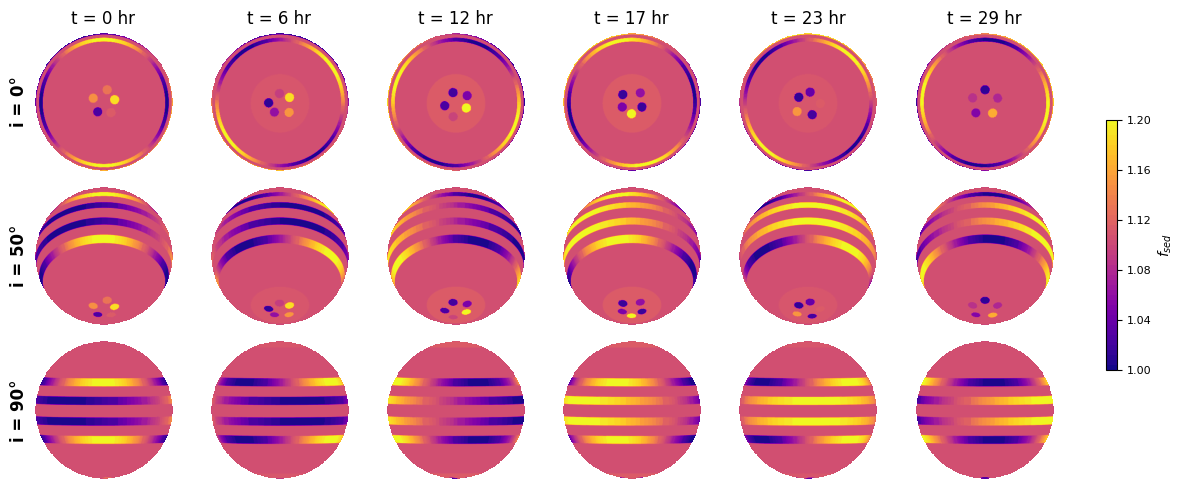

In [73]:
# Plot 2 rows of atmosphere image at two inclinations, each columns at different time
# save = True
save = False
codename = photrunName_td2 + '-' + default_specConfigName

# fig, axes = plt.subplots(2, 6, figsize=(10, 4))
fig, axes = plt.subplots(3, 6, figsize=(11, 5))

if test: fig.suptitle(codename, fontsize=6)

time_indices = [i*23 for i in range(6)]  # select time indices
shift =[0, 0, 0]

# for i, inclin in enumerate(['30', '70']):
for i, inclin in enumerate(['0', '50', '90']):
    for j, t_idx in enumerate(time_indices):
        t_idx += shift[i]
        ax = axes[i, j]
        ax.imshow(codecs_td2[inclin][t_idx]['composite'], cmap='plasma')
        ax.set_xticks([])
        ax.set_yticks([])
        if i==0: ax.set_title(f't = {time_td2[t_idx]:.0f} hr')
        if j==0: ax.set_ylabel(f'i = {inclin}°', fontsize=12, weight='bold')
        for spine in ax.spines.values():
            spine.set_visible(False)

## add a vertical colorbar
cbar_ax = fig.add_axes([1.02, 0.25, 0.01, 0.5])  # [left, bottom, width, height]
bounds = np.linspace(1.0, 1.2, num=51)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=1.0, vmax=1.2))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, boundaries=bounds, ticks=bounds)
cbar.set_label(r'$f_{sed}$', fontsize=10)
cbar.ax.set_yticks(np.linspace(1.0, 1.2, num=6))
cbar.ax.set_yticklabels([f'{x:.2f}' for x in np.linspace(1.0, 1.2, num=6)], fontsize=8)

# # Create discrete colorbar instead of continuous
# bounds = np.linspace(1.0, 1.2, num=21)
# sm = plt.cm.ScalarMappable(cmap='plasma', 
#                            norm=plt.Normalize(vmin=1.0, vmax=1.2))
# sm.set_array([])
# cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.15, 
#                     aspect=30, shrink=0.8, boundaries=bounds, ticks=bounds)
# cbar.set_label(r'$f_{sed}$', fontsize=10)
# cbar.ax.set_xticks(np.linspace(1.0, 1.2, num=11))
# cbar.ax.set_xticklabels([1.0, 1.02, 1.04, 1.06, 1.08, 1.1, 1.12, 1.14, 1.16, 1.18, 1.2], fontsize=8)

plt.tight_layout()
handle = f'atmo_images_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

#### Helpler function for wavebin flux calculation

In [29]:
# calculate binned flux at given wavelength range (take a spectra timeseries array per inclination)
def calculate_wavebin_flux(specs_inclin, wmin, wmax):
        flux_ts = []
        for keys in specs_inclin:
            frame_i, wave_i, flux_i = specs_inclin[keys].values()
            # Find wavelength indices in the bin
            mask = (wave_i >= wmin) & (wave_i <= wmax)
            if np.sum(mask) > 0:
                # Calculate median flux in this bin
                median_flux = np.median(flux_i[mask])
                flux_ts.append(median_flux)
        return flux_ts

### [Figure]: Lightcurves for 3 different wavelength bins for i = 10, 40, 80 | type `ts`

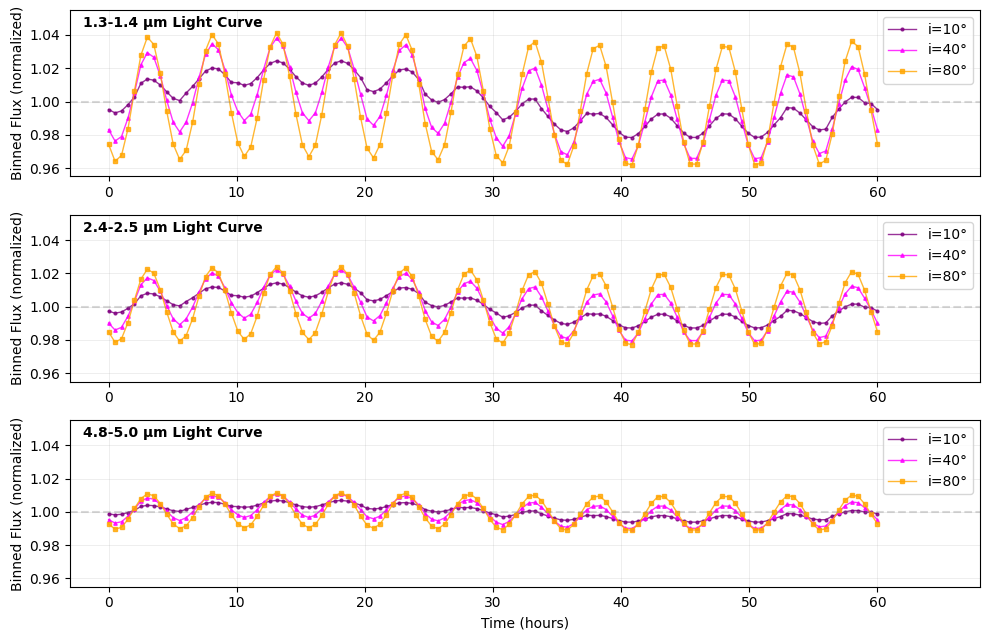

In [ ]:
# save = True
save = False 
normalize = True
codename = photrunName_ts[:-3] + '_' + default_specConfigName

fig, axs = plt.subplots(3, 1, figsize=(10, 6.5))
if test: fig.suptitle(codename, fontsize=6)

wavebin = [ (1.3, 1.4),
            (2.4, 2.5),
            (4.8, 5.0) ]

inc_array = ['10', '40', '80']
markerstyles = ['o', '^', 's']
linestyles = ['-', '-', '-']
# map linestyles to wavemin and create a dictionary

# Define colors for different inclinations
colors = ['purple', 'magenta', 'orange']

for i, (wmin, wmax) in enumerate(wavebin):
    ax = axs[i]
    for j, inclin in enumerate(inc_array):

        ### test static 
        flux_ts = calculate_wavebin_flux(specs_ts[inclin], wmin, wmax)
        
        # Plot normalized light curve
        # normalize flux mean to 1
        if normalize:
            flux_ts = np.array(flux_ts)
            flux_ts = (flux_ts - np.mean(flux_ts)) / np.max(flux_ts) + 1

        ax.plot(time_ts, flux_ts, 
                marker=markerstyles[j], linestyle=linestyles[j], 
                alpha=0.8, color=colors[j],
                linewidth=1, markersize=2+0.5*j,
                label=f'i={inclin}°')

    if i==2: ax.set_xlabel('Time (hours)', fontsize=10)

    if normalize: ax.set_ylabel('Binned Flux (normalized)')
    else: ax.set_ylabel('Binned Flux (erg/cm²/s/Hz)')

    ax.set_xlim(-3, 68)
    if normalize: ax.set_ylim(0.955, 1.055)
    ax.legend(),
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.axhline(1, ls='--', color='gray', alpha=0.3)
    ax.text(-2, 1.045, f'{wmin}-{wmax} μm Light Curve', fontsize=10, weight='bold')

plt.tight_layout()
handle = f'lightcurves_bins_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


### [Figure]: Lightcurves for 3 different wavelength bins for i = 10, 40, 80 | type `ts1`

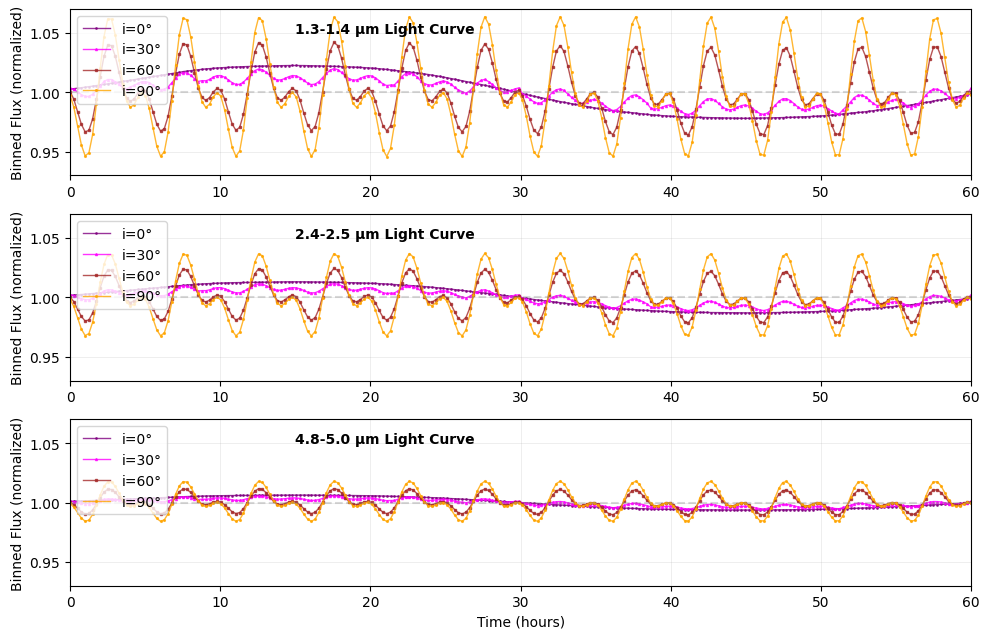

In [59]:
# save = True
save = False 
normalize = True
codename = photrunName_ts1[:-3] + '_' + default_specConfigName

fig, axs = plt.subplots(3, 1, figsize=(10, 6.5))
if test: fig.suptitle(codename, fontsize=6)

wavebin = [ (1.3, 1.4),
            (2.4, 2.5),
            (4.8, 5.0) ]

inc_array = ['0', '30', '60', '90']
markerstyles = ['o', '^', 's', '.']
linestyles = ['-', '-', '-', '-']
# map linestyles to wavemin and create a dictionary

# Define colors for different inclinations
colors = ['purple', 'magenta', 'brown', 'orange']

for i, (wmin, wmax) in enumerate(wavebin):
    ax = axs[i]
    for j, inclin in enumerate(inc_array):

        ### test static 
        flux_ts1 = calculate_wavebin_flux(specs_ts1[inclin], wmin, wmax)
        
        # Plot normalized light curve
        # normalize flux mean to 1
        if normalize:
            flux_ts1 = np.array(flux_ts1)
            flux_ts1 = (flux_ts1 - np.mean(flux_ts1)) / np.max(flux_ts1) + 1
        ### if j==0: apply savgol filter to smooth the light curve
        if j==0:
            flux_ts1 = savgol_filter(flux_ts1, window_length=60, polyorder=3)

        ax.plot(time_ts1, flux_ts1, 
                marker=markerstyles[j], linestyle=linestyles[j], 
                alpha=0.8, color=colors[j],
                linewidth=1, markersize=1+0.5*j,
                label=f'i={inclin}°')

    if i==2: ax.set_xlabel('Time (hours)', fontsize=10)

    if normalize: ax.set_ylabel('Binned Flux (normalized)')
    else: ax.set_ylabel('Binned Flux (erg/cm²/s/Hz)')

    ax.set_xlim(0, 60)
    if normalize: ax.set_ylim(0.93, 1.07)
    ax.legend(loc='upper left'),
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.axhline(1, ls='--', color='gray', alpha=0.3)
    ax.text(15, 1.05, f'{wmin}-{wmax} μm Light Curve', fontsize=10, weight='bold')

plt.tight_layout()
handle = f'lightcurves_bins_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


### [Figure]: Lightcurves for 3 different wavelength bins for i = 10, 40, 80 | type `ts2`

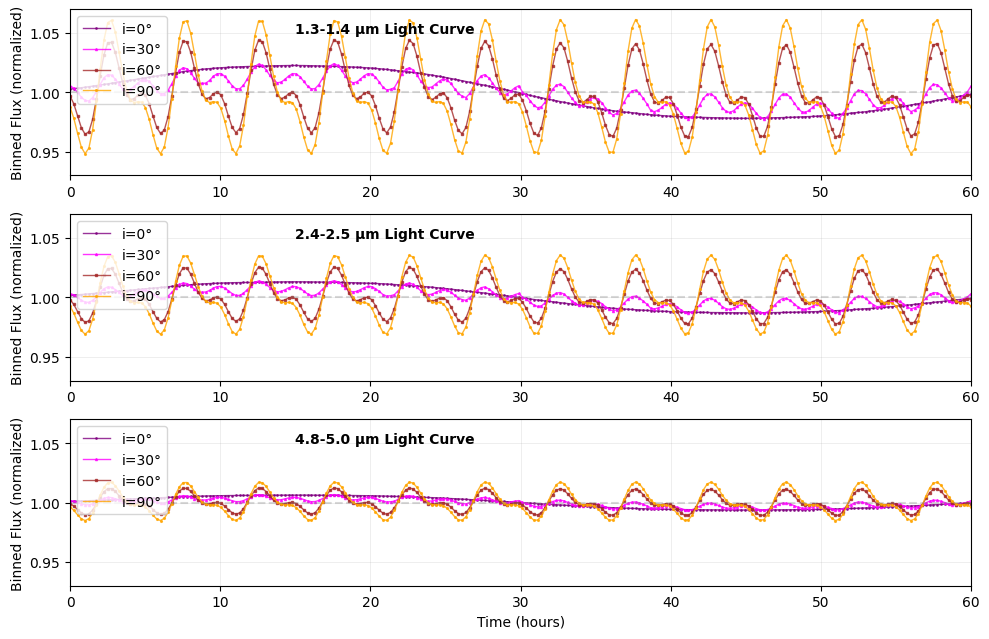

In [60]:
# save = True
save = False 
normalize = True
codename = photrunName_ts2[:-3] + '_' + default_specConfigName

fig, axs = plt.subplots(3, 1, figsize=(10, 6.5))
if test: fig.suptitle(codename, fontsize=6)

wavebin = [ (1.3, 1.4),
            (2.4, 2.5),
            (4.8, 5.0) ]

inc_array = ['0', '30', '60', '90']
markerstyles = ['o', '^', 's', '.']
linestyles = ['-', '-', '-', '-']
# map linestyles to wavemin and create a dictionary

# Define colors for different inclinations
colors = ['purple', 'magenta', 'brown', 'orange']

for i, (wmin, wmax) in enumerate(wavebin):
    ax = axs[i]
    for j, inclin in enumerate(inc_array):

        ### test static 
        flux_ts2 = calculate_wavebin_flux(specs_ts2[inclin], wmin, wmax)
        
        # Plot normalized light curve
        # normalize flux mean to 1
        if normalize:
            flux_ts2 = np.array(flux_ts2)
            flux_ts2 = (flux_ts2 - np.mean(flux_ts2)) / np.max(flux_ts2) + 1
        ### if j==0: apply savgol filter to smooth the light curve
        if j==0:
            flux_ts2 = savgol_filter(flux_ts2, window_length=60, polyorder=3)

        ax.plot(time_ts2, flux_ts2, 
                marker=markerstyles[j], linestyle=linestyles[j], 
                alpha=0.8, color=colors[j],
                linewidth=1, markersize=1+0.5*j,
                label=f'i={inclin}°')

    if i==2: ax.set_xlabel('Time (hours)', fontsize=10)

    if normalize: ax.set_ylabel('Binned Flux (normalized)')
    else: ax.set_ylabel('Binned Flux (erg/cm²/s/Hz)')

    ax.set_xlim(0, 60)
    if normalize: ax.set_ylim(0.93, 1.07)
    ax.legend(loc='upper left'),
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.axhline(1, ls='--', color='gray', alpha=0.3)
    ax.text(15, 1.05, f'{wmin}-{wmax} μm Light Curve', fontsize=10, weight='bold')

plt.tight_layout()
handle = f'lightcurves_bins_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


### [Figure]: Wavelength dependent phase shifts in light curve | type `fsedts`

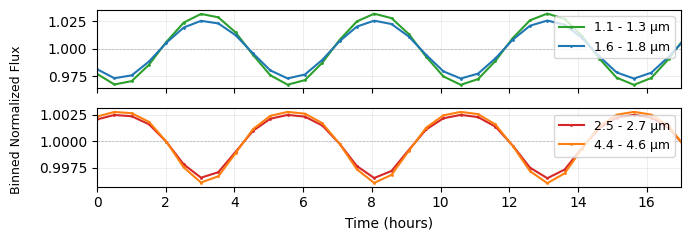

In [235]:
# save = True
save = False 
normalize = True
codename = photrunName_ts[:-3] + '_' + complexFsed_specConfigName

wavebin = [(1.1, 1.3),
        (1.6, 1.8),
        (2.5, 2.7),
        (4.4, 4.6)]

fig, axs = plt.subplots(2, 1, figsize=(7,2.5))
if test: fig.suptitle(codename, fontsize=6)

inclin = '90'
# map linestyles to wavemin and create a dictionary

# Define colors for different inclinations
colors = ['tab:green', 'tab:blue', 'tab:red', 'tab:orange']

for i, (wmin, wmax) in enumerate(wavebin):
    if wmax < 2.5:
        ax = axs[0]
    else:
        ax = axs[1]
    ### test static, complex fsed 
    flux_fsedts = calculate_wavebin_flux(specs_fsedts[inclin], wmin, wmax)
    
    # Plot normalized light curve
    # normalize flux mean to 1
    if normalize:
        flux_fsedts = np.array(flux_fsedts)
        flux_fsedts = (flux_fsedts - np.mean(flux_fsedts)) / np.max(flux_fsedts) +1

    ax.plot(time_fsedts, flux_fsedts, 
            marker='o', alpha=1, color=colors[i], markersize=1,
            linewidth=1.5, label=f'{wmin} - {wmax} μm')
    ax.grid(True, alpha=0.3, lw=0.5)

    # if i==1: ax.set_ylabel('Normalized Flux')
    fig.supylabel('Binned Normalized Flux', fontsize=9)

    if i==3: ax.set_xlabel('Time (hours)')

    ax.set_xlim(0, 17)
    # ax.set_ylim(0.988, 1.012)
    # if normalize: ax.set_ylim(0.955, 1.055)
    ax.legend(loc='upper right', fontsize=9, frameon=True)#, prop={'weight': 'bold'}),
    ax.axhline(1, lw=0.5, ls='--', color='gray', alpha=0.3)
    # ax.text(2, 0.999*np.max(flux_fsedts), f'{wmin}-{wmax} μm Light Curve', fontsize=10, weight='bold')
    if i==len(wavebin)-1: 
        ax.set_xlabel('Time (hours)', fontsize=10)
    if i==0: ax.set_xticklabels([])

plt.tight_layout()
handle = f'lightcurves_bins_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


### [Figure]: Spectral ratio between two inclinations | type `ts`

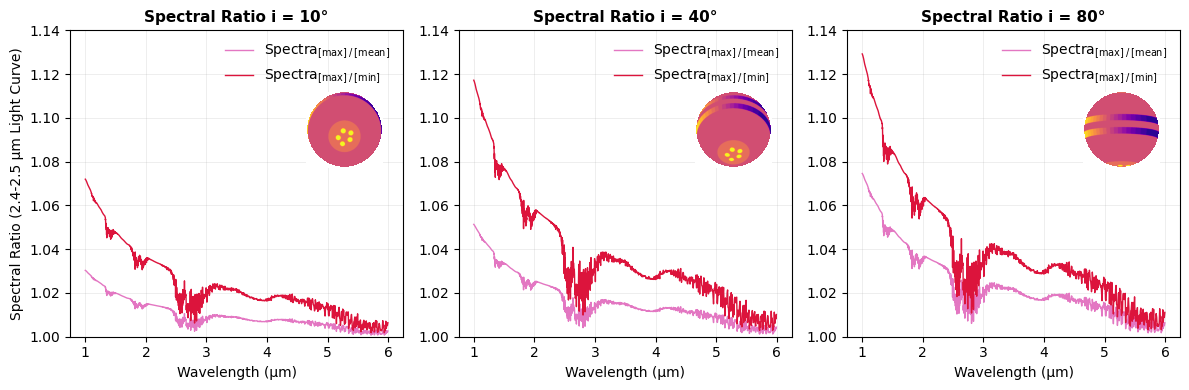

In [375]:
save = True
# save = False
normalize = True
codename = photrunName_ts[:-3] + '-' + default_specConfigName

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
if test: fig.suptitle(photrunName_ts + '-' + default_specConfigName, fontsize=6)

# wmin, wmax = 1.3, 1.4
wmin, wmax = 2.4, 2.5
# wmin, wmax = 4.8, 5.0
inc_array = ['10', '40', '80']

for j, inclin in enumerate(inc_array):
    ax = axs[j]

    flux_ts = calculate_wavebin_flux(specs_ts[inclin], wmin, wmax)
    # find time id where flux is max, mid, min
    flux_ts = np.array(flux_ts)
    max_id = np.argmax(flux_ts)
    min_id = np.argmin(flux_ts)
    mid_id = (max_id + min_id) // 2
    
    framemax, wave, spectramax = specs_ts[inclin][max_id].values()
    framemid, _, spectramid = specs_ts[inclin][mid_id].values()
    framemin, _, spectramin = specs_ts[inclin][min_id].values()

    ax.plot(wave, spectramax/spectramid, lw=1, ls='-',
            label=r'Spectra$_\mathrm{ [max] \:/\: [mean]}$', c='tab:pink')
    ax.plot(wave, spectramax/spectramin, lw=1, ls='-',
            label=r'Spectra$_\mathrm{ [max] \:/\: [min]}$', c='crimson')

    # plot small inset of atmosphere image
    inset_ax = ax.inset_axes([0.7, 0.55, 0.25, 0.25])
    frame_id = 23
    inset_ax.imshow(codecs_ts[inclin][frame_id]['composite'], cmap='plasma')
    inset_ax.set_xticks([]), inset_ax.set_yticks([])
    # turn off the border
    for spine in inset_ax.spines.values():
        spine.set_visible(False)

    ax.set_xlabel('Wavelength (μm)', fontsize=10)
    if j==0: ax.set_ylabel(f'Spectral Ratio ({wmin}-{wmax} μm Light Curve)', fontsize=10)
    ax.set_title(f'Spectral Ratio i = {inclin}°', fontsize=11, weight='bold')
    ax.legend(fontsize=10, frameon=False)
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.set_ylim(1.0, 1.14)

plt.tight_layout()
handle = f'spectral_ratio_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

#### Calculate J-H, J-K colors and variab. amplitude through inclin. | type `ts`

In [74]:
### Calculate J-H, J-K colors and variability amplitudes at all inclinations

colorsJK, colorsJH = [], []
# get amplitudes at 2.4 and 2.8 microns
amplitudes1, amplitudes2, amplitudes3 = [], [], []

wavebin1 = (1.3, 1.4)
wavebin2 = (2.4, 2.5)
wavebin3 = (4.8, 5.0)

for inclin in specs_ts.keys():

    _, wave_i, flux_i = specs_ts[inclin][0].values()
    mean_flux = np.zeros_like(wave_i)

    # Define J, H, K band masks
    color_J_mask = (wave_i >= 1.1) & (wave_i <= 1.4)
    color_H_mask = (wave_i >= 1.5) & (wave_i <= 1.8)
    color_K_mask = (wave_i >= 2.2) & (wave_i <= 2.4)

    bin1_mask = (wave_i >= wavebin1[0]) & (wave_i <= wavebin1[1])
    bin2_mask = (wave_i >= wavebin2[0]) & (wave_i <= wavebin2[1])
    bin3_mask = (wave_i >= wavebin3[0]) & (wave_i <= wavebin3[1])

    # Get amplitude at each wavebins
    flux1, flux2, flux3 = [], [], []
    
    for keys in specs_ts[inclin]:
        _, wave_i, flux_i = specs_ts[inclin][keys].values()
        
        if np.sum(bin1_mask) > 0:
            # Calculate median flux in 2.4um and 2.8um bin
            flux1.append(np.median(flux_i[bin1_mask]))
            flux2.append(np.median(flux_i[bin2_mask]))
            flux3.append(np.median(flux_i[bin3_mask]))

        # Get mean flux for color calculation
        mean_flux += flux_i

    # Calculate 'color' value using mean flux within the J, H, K bands
    mean_flux /= len(specs_ts[inclin].keys())

    color_J_flux = np.mean(mean_flux[color_J_mask])
    color_H_flux = np.mean(mean_flux[color_H_mask])
    color_K_flux = np.mean(mean_flux[color_K_mask])

    colorJK = 2.5 * np.log10(color_J_flux / color_K_flux)
    colorJH = 2.5 * np.log10(color_J_flux / color_H_flux)

    colorsJK.append((float(inclin), colorJK))
    colorsJH.append((float(inclin), colorJH))

    # Calculate variability amplitude at each bins of wavelengths
    amplitudes1.append((float(inclin), 100*(np.max(flux1) - np.min(flux1)) / np.mean(flux1)))
    amplitudes2.append((float(inclin), 100*(np.max(flux2) - np.min(flux2)) / np.mean(flux2)))
    amplitudes3.append((float(inclin), 100*(np.max(flux3) - np.min(flux3)) / np.mean(flux3)))
    

### Read in variability, JH, JK color data from Vos 2017

In [15]:
# =========== Vos 2017 Data ===============
import pandas as pd

vos17dataPath = "/Users/nguyendat/Documents/GitHub/polar_vortice/PolarVortice/spitzerData/processed/vos_2017_table.csv"
nameList = ['Spt','3.6Amp','3.6AmpErr','JAmp','JAmpErr','KepAmp',
            'Period','PeriodErr','vsini','vsiniErr','JKscolor',
            'Inclination','inclinationErr','JKanomaly','JKanomalyErr']
vos17full = pd.read_csv(vos17dataPath, names=nameList, delimiter=';', skiprows=1)

vos17dataPath = '/Users/nguyendat/Documents/GitHub/polar_vortice/PolarVortice/spitzerData/processed/vos_JK_color_anomaly_handInput.csv'
nameList = ['No', 'Inclination', 'JKanomaly', 'inclinationErr1', 'inclinationErr2',
            'JKanomalyErr1', 'JKanomalyErr2']
vos17 = pd.read_csv(vos17dataPath, names=nameList, delimiter=';', skiprows=1)
vos17['inclinationErr1'] = vos17['Inclination'] - vos17['inclinationErr1']
vos17['inclinationErr2'] = vos17['inclinationErr2'] - vos17['Inclination']
vos17['JKanomalyErr1'] = vos17['JKanomaly'] - vos17['JKanomalyErr1']
vos17['JKanomalyErr2'] = vos17['JKanomalyErr2'] - vos17['JKanomaly']

# =========== Suarez 2023 Data ===============
suarez23table1Path = "/Users/nguyendat/Documents/GitHub/polar_vortice/PolarVortice/spitzerData/processed/suarez_2023_table1.csv"
suarez23table1Name = ["2MASSName","ShortName"," SpT(opt)",
                      "Reference1","SpT(IR)","Reference2","SilicateIndex",
                      "Si_err","Inc","IncErr","Reference"]
suarez23table1 = pd.read_csv(suarez23table1Path, delimiter=',', names=suarez23table1Name, skiprows=1)
### 
suarez23table2Path = "/Users/nguyendat/Documents/GitHub/polar_vortice/PolarVortice/spitzerData/processed/suarez_2023_table2.csv"
suarez23table2Name = ["ShortName","J","Jerr","H","Herr",
                      "Ks","Kserr","W1","W1err",
                      "W2","W2err","J-Ks","W1-W2"]
suarez23table2 = pd.read_csv(suarez23table2Path, names=suarez23table2Name, delimiter=',', skiprows=1)
###
suarez23 = suarez23table2.merge(suarez23table1, on='ShortName', how='right')
suarez23['J-H'] = suarez23.J - suarez23.H

In [10]:
suarez23

,ShortName,J,Jerr,H,Herr,Ks,Kserr,W1,W1err,W2,...,SpT(opt),Reference1,SpT(IR),Reference2,SilicateIndex,Si_err,Inc,IncErr,Reference,J-H
0,0036+1821,12.466,0.027,11.588,0.030,11.058,0.021,10.516,0.024,10.237,...,L3.5,Kirk00,L4,Knap04,1.20,0.08,51,9,Vos17,0.878
1,0355+1133,14.050,0.024,12.530,0.031,11.526,0.021,10.528,0.023,9.943,...,L5gamma,Cruz09,L4gamma,Bard19,1.29,0.02,50,2,ThisStudy,1.520
2,0501-0010,14.982,0.038,13.713,0.034,12.963,0.035,12.050,0.024,11.518,...,L4gamma,Cruz09,L4gamma,Gagn15,1.35,0.08,60,10,Vos20,1.269
3,1126-5003,13.997,0.032,13.284,0.036,12.829,0.029,12.218,0.024,11.942,...,L4.5,Burg08,L6.5p,Burg08,1.01,0.04,35,7,Vos20,0.713
4,1425-3650,13.747,0.028,12.575,0.022,11.805,0.027,10.998,0.022,10.576,...,L3,Reid08,L4gamma,Gagn15,1.32,0.04,54,23,Vos20,1.172
5,1507-1627,12.830,0.027,11.895,0.024,11.312,0.026,10.667,0.023,10.378,...,L5,Kirk00,L5.5,Knap04,1.02,0.02,23,2,Vos17,0.935
6,1721+3344,13.625,0.023,12.952,0.026,12.489,0.020,11.933,0.024,11.601,...,L3,Cruz03,L5,Burg08,1.09,0.05,27,4,Vos17,0.673
7,1821+1414,13.431,0.024,12.396,0.019,11.650,0.021,10.845,0.029,10.478,...,L4.5,Loop08,L5p,Kirk10,1.25,0.01,61,17,Vos17,1.035
8,2148+4003,14.147,0.029,12.783,0.030,11.765,0.023,10.739,0.023,10.235,...,L6,Loop05,L6.5p,Kirk10,1.44,0.01,88,5,Vos17,1.364
9,2244+2043,16.476,0.140,14.999,0.066,14.022,0.073,12.777,0.024,12.108,...,L6.5,Kirk08,L6-L8gamma,Gagn15,1.37,0.07,76,17,Vos08,1.477


In [11]:
vos17full

,Spt,3.6Amp,3.6AmpErr,JAmp,JAmpErr,KepAmp,Period,PeriodErr,vsini,vsiniErr,JKscolor,Inclination,inclinationErr,JKanomaly,JKanomalyErr
2M1906+40,L1,NaN,NaN,NaN,NaN,1.5,8.900,0.000,11.20,2.20,1.31,82,10.0,1.34,0.02
2M1721+33,L3,0.33,0.07,NaN,NaN,NaN,2.600,0.100,NaN,NaN,1.14,27,4.0,1.60,0.02
2M2208+29,L3,0.69,0.07,NaN,NaN,NaN,3.500,0.200,NaN,NaN,1.65,55,10.0,1.60,0.02
DENIS 1058*,L3,0.39,0.04,0.843,NaN,NaN,4.300,0.310,37.50,2.50,1.62,90,2.0,1.60,0.02
2M0036+18,L3.5,0.47,0.05,1.220,0.04,NaN,2.700,0.300,35.12,0.57,1.41,51,9.0,1.69,0.02
2M0103+19,L4,0.47,0.05,NaN,NaN,NaN,2.700,0.300,NaN,NaN,2.14,40,8.0,1.77,0.05
2M1615+49,L4,0.90,0.20,NaN,NaN,NaN,24.000,0.000,NaN,NaN,2.47,86,7.0,1.77,0.05
2M1126-50,L4.5,0.21,0.04,1.200,0.10,NaN,3.200,0.300,NaN,NaN,1.17,35,7.0,1.77,0.05
2M1821+14,L4.5,0.54,0.05,NaN,NaN,NaN,4.200,0.100,28.85,0.16,1.78,61,17.0,1.77,0.05
2M1507-16,L5,0.57,0.04,NaN,NaN,NaN,2.500,0.100,21.27,1.86,1.51,23,2.0,1.78,0.05


In [12]:
vos17

,No,Inclination,JKanomaly,inclinationErr1,inclinationErr2,JKanomalyErr1,JKanomalyErr2
0,1,22.931034,-0.261504,1.638034,1.748966,0.048496,0.051504
1,2,27.259852,-0.464633,3.659852,3.740148,-0.044633,-0.035367
2,3,35.800493,-0.598764,7.400493,7.499507,0.051236,0.048764
3,4,40.363300,0.122705,8.306300,8.436700,0.049705,0.049295
4,5,52.062808,-0.362138,9.362808,9.357192,0.047862,0.052138
5,6,53.115764,0.146095,2.615764,2.684236,0.066095,0.063905
6,7,56.040640,-0.358722,9.840640,9.819360,0.031278,0.038722
7,8,56.274631,0.385549,17.664631,17.785369,0.045549,0.034451
8,9,62.007389,-0.086385,17.537389,17.432611,0.038615,0.039385
9,10,80.141626,0.071618,16.621626,10.758374,0.107618,0.111382


### [Figure]: Plotting Vos 2017 data to JK vs inclination and Variab. amplitude 

In [75]:
def rescale_to_range(x, new_min, new_max):
    x = np.asarray(x)
    xmin, xmax = x.min(), x.max()
    if xmax == xmin:
        return np.full_like(x, new_min)
    return (x - xmin) / (xmax - xmin) * (new_max - new_min) + new_min

In [78]:
colorsJK

array([-0.59876444, -0.56868521, -0.46082652, -0.29567507, -0.10403631,
        0.09741271,  0.30502516,  0.51478059,  0.65003093,  0.68157958])

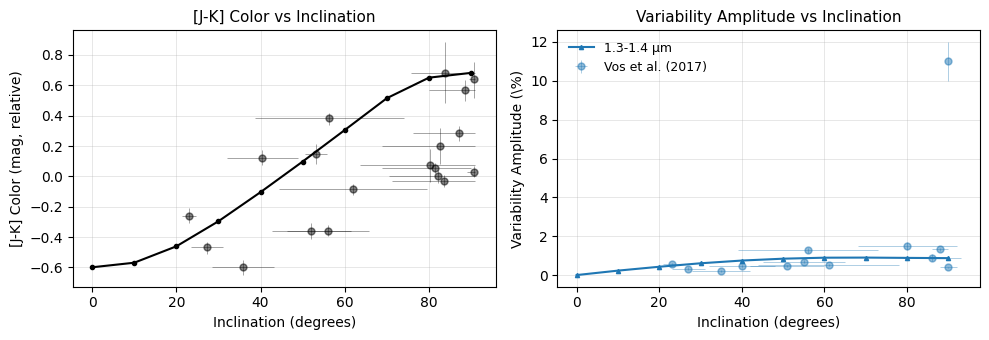

In [ ]:
# ======= Overplot Vos17 data with Relative J-K and Variability amplitude vs Inclination Plot =======
# save = True
save = False

# Color inclination + JK color anomaly
inclination = vos17['Inclination']
incErr1 = vos17['inclinationErr1'].values
incErr2 = vos17['inclinationErr2'].values
xerrs = np.array([incErr1, incErr2])

JKscolorAnomaly = vos17['JKanomaly']
JKanomalyErr1 = np.abs(vos17['JKanomalyErr1'].values)
JKanomalyErr2 = np.abs(vos17['JKanomalyErr2'].values)
yerrs = np.array([JKanomalyErr1, JKanomalyErr2])

# Variability + Jamp amplitude
# [inclin, inclinerr, Jamp, Jamperr] = vos17full.query('JAmp>0')[['Inclination', 'inclinationErr', 'JAmp', 'JAmpErr']].values.T
# Variability + 3.6um amplitude
[inclin, inclinerr, amp, amperr] = vos17full.query('`3.6Amp` > 0')[['Inclination', 'inclinationErr', '3.6Amp', '3.6AmpErr']].values.T

# Plot color vs inclination
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 3.5))

codename = photrunName_ts[:-3] + '-' + default_specConfigName
if test: fig.suptitle(codename, fontsize=6)

JK_inc = colorsJK
_, amplitudes1_inc = zip(*amplitudes1)

JK_inc_mean, JH_inc_mean = np.mean(JK_inc), np.mean(JH_inc)
modelJK = JK_inc - JK_inc_mean
modelJK = rescale_to_range(modelJK, JKscolorAnomaly.min(), np.sort(JKscolorAnomaly.max())

ax1.plot(inclinations, modelJK, marker='.', linestyle='-', c='k')

### Plot data
ax1.errorbar(x=inclination, y=JKscolorAnomaly, xerr=xerrs, yerr=yerrs,
            ls='', marker='o', lw=0.5, ms=5, c='k', 
            alpha=0.5, label='Vos et al. (2017)')

ax1.set_title(f'[J-K] Color vs Inclination', fontsize=11)
ax1.set_xlabel('Inclination (degrees)')
ax1.set_ylabel('[J-K] Color (mag, relative)')
ax1.grid(True, alpha=0.3, lw=0.7)

# Plot variability amplitude vs inclination
### Scaling
### Plot simulated

# remove the most aggregious data point at 11%
amprescaled = rescale_to_range(np.array(amplitudes1_inc), 0, np.sort(amp)[-5])

ax2.plot(inclinations, amprescaled, marker='^', markersize=3, linestyle='-', 
         c='tab:blue', label=f'{wavebin1[0]:.1f}-{wavebin1[1]:.1f} μm')
### Plot data
ax2.errorbar(x=inclin, y=amp, xerr=inclinerr, yerr=amperr,
            ls='', marker='o', lw=0.5, ms=5, c='tab:blue', 
            alpha=0.5, label='Vos et al. (2017)')

ax2.set_title(f'Variability Amplitude vs Inclination', fontsize=11)
ax2.set_xlabel('Inclination (degrees)')
ax2.set_ylabel('Variability Amplitude (\%)')
ax2.legend(frameon=False, fontsize=9)
ax2.grid(True, alpha=0.3, lw=0.7)
ax2.set_ylim(0,2)

plt.tight_layout()
if save:
    handle = f'vos17_JKcolor+3.6um_variability_inclination_{codename}.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close('all')

In [49]:
amplitudes1_inc

(3.4817151634381385,
 4.726172256043884,
 5.810638006446937,
 6.782735598747805,
 7.549803206996487,
 8.071698119767408,
 8.351263614497473,
 8.379244679421854,
 8.295794058284777,
 8.224289795492108)

### [Figure]: J-H, J-K colors and variab. amplitude through inclin. | type `ts`

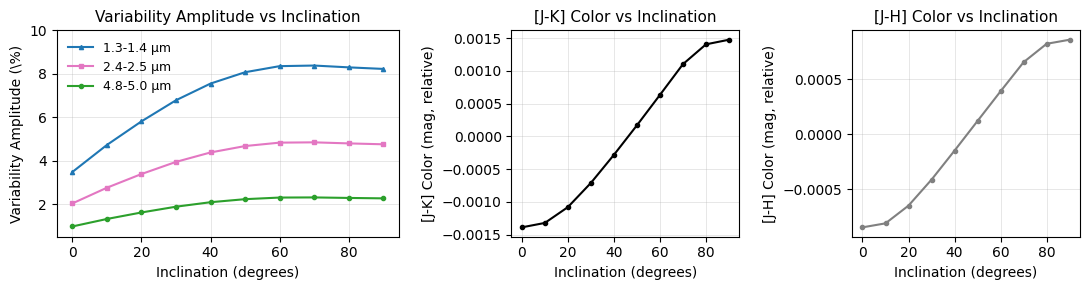

In [558]:
# ======= Relative J-K and J-H Color and variability amplitude vs Inclination Plot =======
save = True
# save = False

# Plot color vs inclination
fig, [ax3, ax1, ax2] = plt.subplots(1, 3, figsize=(11, 3.), width_ratios=[1.5, 1, 1])

codename = photrunName_ts[:-3] + '-' + default_specConfigName
if test: fig.suptitle(codename, fontsize=6)

inclinations, JK_inc = zip(*colorsJK)
_, JH_inc = zip(*colorsJH)
_, amplitudes1_inc = zip(*amplitudes1)
_, amplitudes2_inc = zip(*amplitudes2)
_, amplitudes3_inc = zip(*amplitudes3)

JK_inc_mean, JH_inc_mean = np.mean(JK_inc), np.mean(JH_inc)
ax1.plot(inclinations, JK_inc - JK_inc_mean, marker='.', linestyle='-', 
         c='k')
ax1.set_title(f'[J-K] Color vs Inclination', fontsize=11)
ax1.set_xlabel('Inclination (degrees)')
ax1.set_ylabel('[J-K] Color (mag, relative)')
ax1.grid(True, alpha=0.3, lw=0.7)

ax2.plot(inclinations, JH_inc - JH_inc_mean, marker='.', linestyle='-',
        c='gray')
ax2.set_title(f'[J-H] Color vs Inclination', fontsize=11)
ax2.set_xlabel('Inclination (degrees)')
ax2.set_ylabel('[J-H] Color (mag, relative)')
ax2.grid(True, alpha=0.3, lw=0.7)

# Plot variability amplitude vs inclination
ax3.plot(inclinations, amplitudes1_inc, marker='^', markersize=3, linestyle='-', 
         c='tab:blue', label=f'{wavebin1[0]:.1f}-{wavebin1[1]:.1f} μm')
ax3.plot(inclinations, amplitudes2_inc, marker='s', markersize = 3, linestyle='-',
         c='tab:pink', label=f'{wavebin2[0]:.1f}-{wavebin2[1]:.1f} μm ')
ax3.plot(inclinations, amplitudes3_inc, marker='o', markersize=3, linestyle='-',
         c='tab:green', label=f'{wavebin3[0]:.1f}-{wavebin3[1]:.1f} μm ')
ax3.set_title(f'Variability Amplitude vs Inclination', fontsize=11)
ax3.set_xlabel('Inclination (degrees)')
ax3.set_ylabel('Variability Amplitude (\%)')
ax3.legend(frameon=False, fontsize=9)
ax3.grid(True, alpha=0.3, lw=0.7)
ax3.set_ylim(0.5,10)

plt.tight_layout()
if save:
    handle = f'color_inclination_{codename}.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

### [Figure] Periodogram comparisons: different inclinations | type `ts`

/var/folders/n_/ynkgs9fs2ts72fkcb79xcjlh0000gn/T/ipykernel_6621/2288096765.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


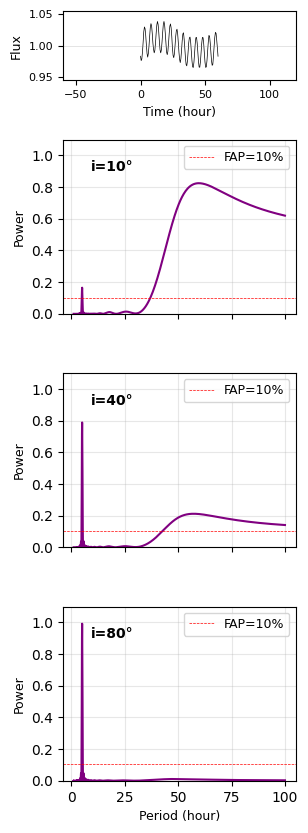

In [525]:
### Periodogram of lightcurve in hours 
from PyAstronomy.pyTiming import pyPeriod
save = True
# save = False
codename = photrunName_ts[:-3] + '-' + default_specConfigName

fig = plt.figure(figsize=(3, 10))
gs = fig.add_gridspec(4, 1, height_ratios=[0.4, 1, 1, 1], hspace=0.4)

axs = []
axs.append(fig.add_subplot(gs[0]))  # Independent axis
axs.append(fig.add_subplot(gs[1]))  # First of shared group
axs.append(fig.add_subplot(gs[2], sharex=axs[1]))  # Share with axs[1]
axs.append(fig.add_subplot(gs[3], sharex=axs[1]))  # Share with axs[1]

if test: fig.suptitle(photrunName_ts + '-' + default_specConfigName, fontsize=6)
wmin, wmax = 1.3, 1.4
inc_array = ['10', '40', '80']

# Light curve panel
ax0 = axs[0]
flux_ts = calculate_wavebin_flux(specs_ts['40'], wmin, wmax)
# normalize flux mean to 1
flux_ts = np.array(flux_ts)
flux_ts = (flux_ts - np.mean(flux_ts)) / np.max(flux_ts) + 1
ax0.plot(time_ts, flux_ts, color='k', lw=0.5)
ax0.set_xlabel('Time (hour)', fontsize=9)
ax0.set_ylabel('Flux', fontsize=9)
ax0.tick_params(labelsize=8)
ax0.set_ylim(0.945, 1.055)
ax0.set_xlim(-60, 120)
ax0.axhline(1, ls='-', color='gray', alpha=0.3, lw=0.5)

for i, inclin in enumerate(inc_array):
    ax = axs[i+1]
    freqs = np.linspace(0.01, 1, 10000) 
    flux_ts = calculate_wavebin_flux(specs_ts[inclin], wmin, wmax)
    flux_ts = np.array(flux_ts)
    lombscargle = pyPeriod.Gls(# (time, flux, flux_err)
        (time_ts, flux_ts, 0.001*flux_ts), freq=freqs)
    period = 1/lombscargle.freq
    power = lombscargle.power
    fap = 0.1 # false alarm probability
    fapLevel = lombscargle.powerLevel(fap)
    
    # Plot the periodogram
    ax.plot(period, power, color='purple')
    ax.axhline(fapLevel, color='red', ls='--', 
                lw=0.5, label=f'FAP={int(100*fap)}%')
    
    if i == 2: 
        ax.set_xlabel('Period (hour)', fontsize=9)
    else:
        ax.tick_params(labelbottom=False)  # Hide x-tick labels for upper panels
    
    ax.set_ylabel('Power', fontsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.10)
    ax.text(9, 0.9, f'i={inclin}°', fontsize=10, weight='bold')

plt.tight_layout()

if save:
    handle = f'60hr_periodograms_vs_inclination_{codename}.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

### [Figure] Periodogram comparisons: different inclinations | type `js`

/var/folders/n_/ynkgs9fs2ts72fkcb79xcjlh0000gn/T/ipykernel_6621/3355546771.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


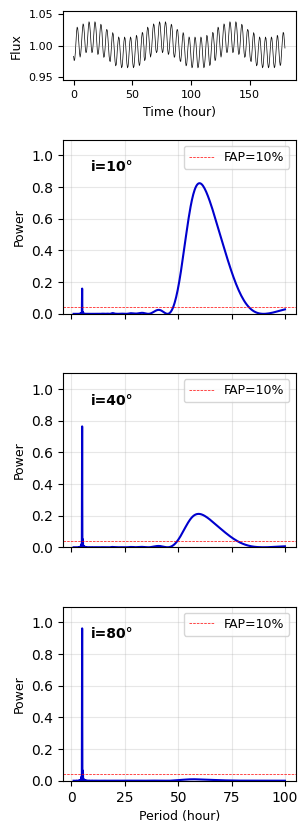

In [526]:
### Periodogram of lightcurve in hours of JWST static case
from PyAstronomy.pyTiming import pyPeriod

save = True
# save = False
codename = photrunName_js[:-3] + '-' + default_specConfigName

fig = plt.figure(figsize=(3, 10))
gs = fig.add_gridspec(4, 1, height_ratios=[0.4, 1, 1, 1], hspace=0.4)

axs = []
axs.append(fig.add_subplot(gs[0]))  # Independent axis
axs.append(fig.add_subplot(gs[1]))  # First of shared group
axs.append(fig.add_subplot(gs[2], sharex=axs[1]))  # Share with axs[1]
axs.append(fig.add_subplot(gs[3], sharex=axs[1]))  # Share with axs[1]

if test: fig.suptitle(photrunName_js + '-' + default_specConfigName, fontsize=6)

wmin, wmax = 1.3, 1.4
inc_array = ['10', '40', '80']

# Light curve panel

ax0 = axs[0]
flux_js = calculate_wavebin_flux(specs_js['40'], wmin, wmax)
# normalize flux mean to 1
flux_js = np.array(flux_js)
flux_js = (flux_js - np.mean(flux_js)) / np.max(flux_js) + 1
ax0.plot(time_js_corrected, flux_js, color='k', lw=0.5)
ax0.set_xlabel('Time (hour)', fontsize=9)
ax0.set_ylabel('Flux', fontsize=9)
ax0.tick_params(labelsize=8)
ax0.set_ylim(0.945, 1.055)
ax0.axhline(1, ls='-', color='gray', alpha=0.3, lw=0.5)

for i, inclin in enumerate(inc_array):
    ax = axs[i+1]

    freqs = np.linspace(0.01, 1, 10000) 

    flux_js = calculate_wavebin_flux(specs_js[inclin], wmin, wmax)
    flux_js = np.array(flux_js)
    lombscargle = pyPeriod.Gls(# (time, flux, flux_err)
        (time_js_corrected, flux_js, 0.001*flux_js), freq=freqs)

    period = 1/lombscargle.freq
    power = lombscargle.power

    fap = 0.1 # false alarm probability
    fapLevel = lombscargle.powerLevel(fap)

    # Plot the periodogram
    ax.plot(period, power, color='mediumblue')
    ax.axhline(fapLevel, color='red', ls='--', 
                lw=0.5, label=f'FAP={int(100*fap)}%')
    if i==2: 
        ax.set_xlabel('Period (hour)', fontsize=9)
    else:
        ax.tick_params(labelbottom=False)  # Hide x-tick labels for upper panels
    
    ax.set_ylabel('Power', fontsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.10)
    ax.text(9, 0.9, f'i={inclin}°', fontsize=10, weight='bold')

plt.tight_layout()
if save:
    handle = f'180hr_periodograms_vs_inclination_{codename}.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

Corrected time_js shape:  (360,)


/var/folders/n_/ynkgs9fs2ts72fkcb79xcjlh0000gn/T/ipykernel_6621/1922083779.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


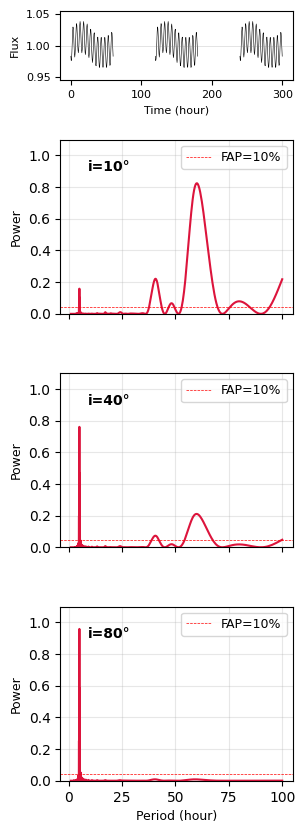

In [528]:
### Periodogram of lightcurve in hours of JWST static case, but with gaps between visit
from PyAstronomy.pyTiming import pyPeriod

save = True
# save = False
codename = photrunName_js[:-3] + '-' + default_specConfigName

# temp fix: recreate time_js correctly by concatenating time_ts three times, with gap of 60 in between
gaps = [0, 120, 240] # 300 hour baseline
time_js_corrected2 = np.concatenate([time_ts + gaps[0], time_ts + gaps[1], time_ts + gaps[2]])
print("Corrected time_js shape: ", time_js_corrected2.shape)

fig = plt.figure(figsize=(3, 10))
gs = fig.add_gridspec(4, 1, height_ratios=[0.4, 1, 1, 1], hspace=0.4)

axs = []
axs.append(fig.add_subplot(gs[0]))  # Independent axis
axs.append(fig.add_subplot(gs[1]))  # First of shared group
axs.append(fig.add_subplot(gs[2], sharex=axs[1]))  # Share with axs[1]
axs.append(fig.add_subplot(gs[3], sharex=axs[1]))  # Share with axs[1]

if test: fig.suptitle(photrunName_js + '-' + default_specConfigName, fontsize=6)

wmin, wmax = 1.3, 1.4
inc_array = ['10', '40', '80']

# Light curve panel

ax0 = axs[0]
flux_ts = calculate_wavebin_flux(specs_ts['40'], wmin, wmax)
# normalize flux mean to 1
flux_ts = np.array(flux_ts)
flux_ts = (flux_ts - np.mean(flux_ts)) / np.max(flux_ts) + 1
for counter in gaps:
    ax0.plot(time_ts+counter, flux_ts, color='k', lw=0.4)
ax0.set_xlabel('Time (hour)', fontsize=8)
ax0.set_ylabel('Flux', fontsize=8)
ax0.tick_params(labelsize=8)
ax0.set_ylim(0.945, 1.055)
ax0.axhline(1, ls='-', color='gray', alpha=0.3, lw=0.5)

for i, inclin in enumerate(inc_array):
    ax = axs[i+1]

    freqs = np.linspace(0.01, 1, 10000) 

    flux_js = calculate_wavebin_flux(specs_js[inclin], wmin, wmax)
    flux_js = np.array(flux_js)
    lombscargle = pyPeriod.Gls(# (time, flux, flux_err)
        (time_js_corrected2, flux_js, 0.001*flux_js), freq=freqs)

    period = 1/lombscargle.freq
    power = lombscargle.power

    fap = 0.1 # false alarm probability
    fapLevel = lombscargle.powerLevel(fap)

    # Plot the periodogram
    ax.plot(period, power, color='crimson')
    ax.axhline(fapLevel, color='red', ls='--', 
                lw=0.5, label=f'FAP={int(100*fap)}%')
    if i==2: 
        ax.set_xlabel('Period (hour)', fontsize=9)
    else:
        ax.tick_params(labelbottom=False)  # Hide x-tick labels for upper panels
    
    ax.set_ylabel('Power', fontsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.10)
    ax.text(9, 0.9, f'i={inclin}°', fontsize=10, weight='bold')

plt.tight_layout()
if save:
    handle = f'300hr_periodograms_vs_inclination_{codename}.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

Corrected time_js shape:  (360,)


/var/folders/n_/ynkgs9fs2ts72fkcb79xcjlh0000gn/T/ipykernel_6621/1155063419.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


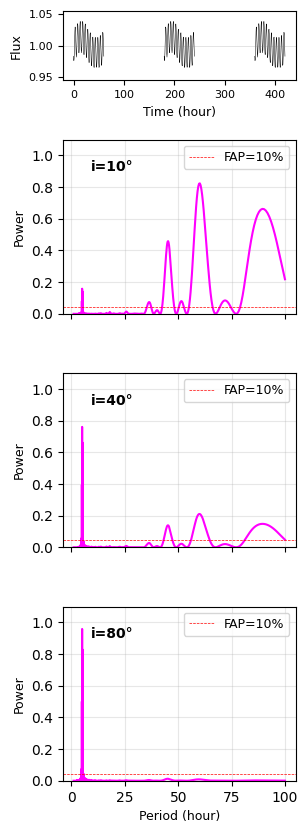

In [527]:
### Periodogram of lightcurve in hours of JWST static case, but with gaps between visit
from PyAstronomy.pyTiming import pyPeriod

save = True
# save = False
codename = photrunName_js[:-3] + '-' + default_specConfigName

# temp fix: recreate time_js correctly by concatenating time_ts three times, with gap of 60 in between
gaps = [0, 180, 360] # 420 hour baseline
time_js_corrected2 = np.concatenate([time_ts + gaps[0], time_ts + gaps[1], time_ts + gaps[2]])
print("Corrected time_js shape: ", time_js_corrected2.shape)

fig = plt.figure(figsize=(3, 10))
gs = fig.add_gridspec(4, 1, height_ratios=[0.4, 1, 1, 1], hspace=0.4)

axs = []
axs.append(fig.add_subplot(gs[0]))  # Independent axis
axs.append(fig.add_subplot(gs[1]))  # First of shared group
axs.append(fig.add_subplot(gs[2], sharex=axs[1]))  # Share with axs[1]
axs.append(fig.add_subplot(gs[3], sharex=axs[1]))  # Share with axs[1]

if test: fig.suptitle(photrunName_js + '-' + default_specConfigName, fontsize=6)

wmin, wmax = 1.3, 1.4
inc_array = ['10', '40', '80']

# Light curve panel

ax0 = axs[0]
flux_ts = calculate_wavebin_flux(specs_ts['40'], wmin, wmax)
# normalize flux mean to 1
flux_ts = np.array(flux_ts)
flux_ts = (flux_ts - np.mean(flux_ts)) / np.max(flux_ts) + 1
for counter in gaps:
    ax0.plot(time_ts+counter, flux_ts, color='k', lw=0.35)
ax0.set_xlabel('Time (hour)', fontsize=9)
ax0.set_ylabel('Flux', fontsize=9)
ax0.tick_params(labelsize=8)
ax0.set_ylim(0.945, 1.055)
ax0.axhline(1, ls='-', color='gray', alpha=0.3, lw=0.5)

for i, inclin in enumerate(inc_array):
    ax = axs[i+1]

    freqs = np.linspace(0.01, 1, 10000) 

    flux_js = calculate_wavebin_flux(specs_js[inclin], wmin, wmax)
    flux_js = np.array(flux_js)
    lombscargle = pyPeriod.Gls(# (time, flux, flux_err)
        (time_js_corrected2, flux_js, 0.001*flux_js), freq=freqs)

    period = 1/lombscargle.freq
    power = lombscargle.power

    fap = 0.1 # false alarm probability
    fapLevel = lombscargle.powerLevel(fap)

    # Plot the periodogram
    ax.plot(period, power, color='magenta')
    ax.axhline(fapLevel, color='red', ls='--', 
                lw=0.5, label=f'FAP={int(100*fap)}%')
    if i==2: 
        ax.set_xlabel('Period (hour)', fontsize=9)
    else:
        ax.tick_params(labelbottom=False)  # Hide x-tick labels for upper panels
    
    ax.set_ylabel('Power', fontsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.10)
    ax.text(9, 0.9, f'i={inclin}°', fontsize=10, weight='bold')

plt.tight_layout()
if save:
    handle = f'420hr_periodograms_vs_inclination_{codename}.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

### Figure: Plot flux-value non-codecized for only-vortex scenarios | type `vs, vd1, vd2` 
- time config: 0-180 hours, 120 frames
- vd1 have different phase offset values from vd2

In [12]:
# Load your data
photometryh5dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/'

### test onlyVortex static/dynamic
photrunName = 'test_onlyVortex_v0_static.h5'
phot_vs, specs_vs, codecs_vs, codec_loaded_vs = read_spec_codecs(photrunName)

photrunName = 'test_onlyVortex_v0_dynamic1.h5'
phot_vd1, specs_vd1, codecs_vd1, codec_loaded_vd1 = read_spec_codecs(photrunName)

photrunName = 'test_onlyVortex_v0_dynamic2.h5'
phot_vd2, specs_vd2, codecs_vd2, codec_loaded_vd2 = read_spec_codecs(photrunName)

Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_onlyVortex_v0_static_1200k_clouds=20/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20
Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_onlyVortex_v0_dynamic1_1200k_clouds=20/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20
Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_mo

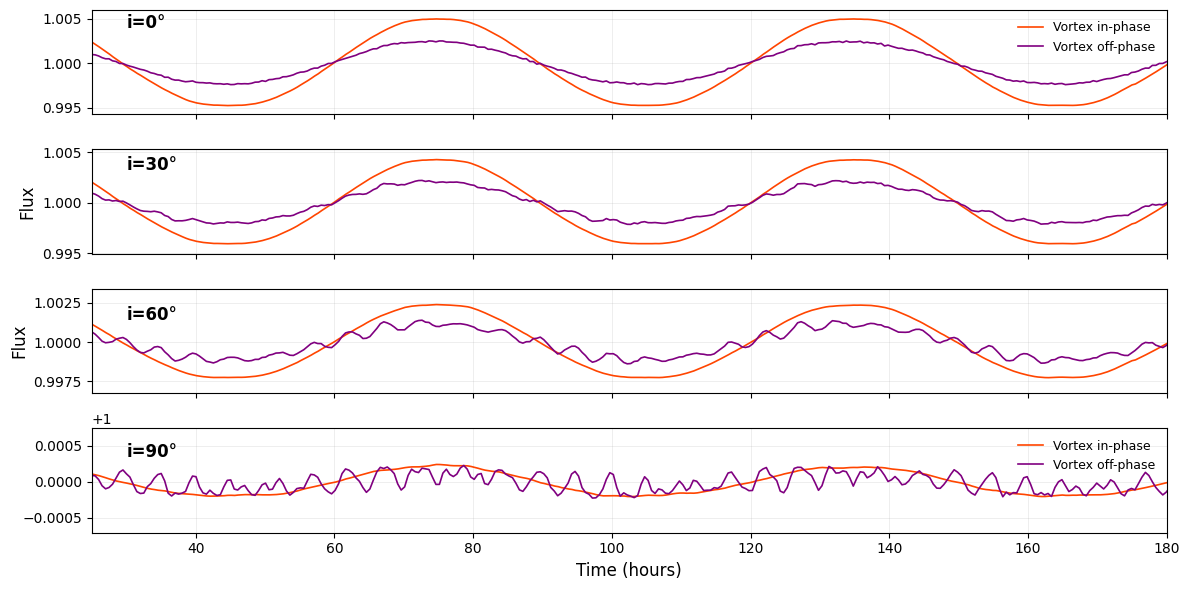

In [33]:
save = True
# save = False

fig, axs = plt.subplots(4,1, figsize=(12, 6), sharex=True)
wmin, wmax = 1.3, 1.4
for i, inclin in enumerate(['0', '30', '60', '90']):
    ax = axs[i]
    time = phot_vs[inclin]['time_array']

    flux_vs = calculate_wavebin_flux(specs_vs[inclin], wmin, wmax)
    flux_vd1 = calculate_wavebin_flux(specs_vd1[inclin], wmin, wmax)
    flux_vd2 = calculate_wavebin_flux(specs_vd2[inclin], wmin, wmax)
        
    # normalize flux mean to 1
    flux_vs = np.array(flux_vs)
    flux_vs = (flux_vs - np.mean(flux_vs)) / np.max(flux_vs) + 1
    flux_vd1 = np.array(flux_vd1)
    flux_vd1 = (flux_vd1 - np.mean(flux_vd1)) / np.max(flux_vd1) + 1
    flux_vd2 = np.array(flux_vd2)
    flux_vd2 = (flux_vd2 - np.mean(flux_vd2)) / np.max(flux_vd2) + 1    

    flux_vs = savgol_filter(flux_vs, 20, 2)

    ax.plot(time, flux_vs, label='Vortex in-phase', lw=1.2, ls='-', c='orangered')
    # ax.plot(time, flux_vd1, label='Vortex in-phase', lw=1)
    ax.plot(time+25, flux_vd2, label='Vortex off-phase', lw=1.2, c='purple', ls='-')
    if inclin == '90': ax.set_xlabel('Time (hours)', fontsize=12)
    if inclin in ['30', '60']: ax.set_ylabel('Flux', fontsize=12)
    if inclin in ['0', '90']: ax.legend(loc='upper right', fontsize=9, frameon=False)
    
    ax.set_xlim(25,180)
    
    if inclin=='90':
        ax.set_ylim(np.min(flux_vs) - 0.0005*np.min(flux_vs), np.max(flux_vs) + 0.0005*np.max(flux_vs))
        ax.text(30, np.max(flux_vs) + 0.0001*np.max(flux_vs), f'i={inclin}°', fontsize=12, weight='bold')
    else:
        ax.set_ylim(np.min(flux_vs) - 0.001*np.min(flux_vs), np.max(flux_vs) + 0.001*np.max(flux_vs))
        ax.text(30, np.max(flux_vs) - 0.001*np.max(flux_vs), f'i={inclin}°', fontsize=12, weight='bold')

    ax.grid(True, alpha=0.3, linewidth=0.5)

plt.tight_layout()
if save:
    handle = f'onlyVortex_lightcurve_at_inclin_comparison.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()
plt.close()



### Figure: Vortices polar view + evolution path | all types


Polar view:
  r_inner (lat 90°) = 7.50
  r_outer (lat 65°) = 15.00


/var/folders/n_/ynkgs9fs2ts72fkcb79xcjlh0000gn/T/ipykernel_6621/3499860389.py:51: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x, y, '-', color=colors[i], alpha=0.8,


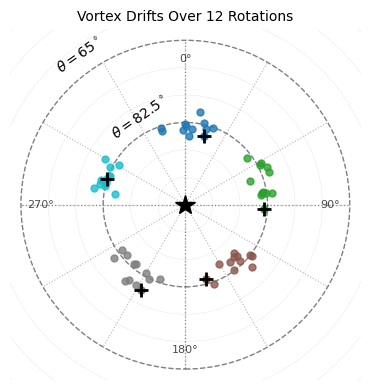

In [ ]:
vortexPaths = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/default120_vortex_paths.pkl'
vortex_paths = pickle.load(open(vortexPaths, 'rb'))

save = True
# save = False

verbose = False
# Set up band_config: latitudinal features
Ppol, Pband, Prot = 60, 5, 5  # Periods in hours
Fpolar, Fband, Fambient = 0.98, 1, 1 # amp
Fpolar_var, Fband_var, Fambient_var = 0.05, 0.15, 0.00 # variab

lat2, lat1, amp, typ, phase, period, planet_period, variab = [90, 65, Fpolar, 'P', 0, Ppol, Prot, Fpolar_var]
center_lat = 82.5

if lat1 < lat2:
    lat1, lat2 = lat2, lat1

# ======= Plot vortex paths in polar view =======
fig, ax = plt.subplots(figsize=(4,4))
ax.set_aspect('equal')
colors = plt.cm.tab10(np.linspace(0, 1, 5))

# Polar cap boundaries
r_inner = 90 - center_lat
r_outer = 15

print(f"\nPolar view:")
print(f"  r_inner (lat {lat1}°) = {r_inner:.2f}")
print(f"  r_outer (lat {lat2}°) = {r_outer:.2f}")

for i in range(5):
    lons = np.array(vortex_paths[i]['lons'])
    lats = np.array(vortex_paths[i]['lats'])
    
    # Convert to polar coordinates
    r = 90 - lats
    theta = np.radians(lons)
    
    # Convert to Cartesian
    x = r * np.sin(theta)
    y = r * np.cos(theta)
    
    if verbose:
        print(f"\nVortex {i} in polar coords:")
        print(f"  r: min={r.min():.2f}, max={r.max():.2f}")
        print(f"  x: min={x.min():.2f}, max={x.max():.2f}")
        print(f"  y: min={y.min():.2f}, max={y.max():.2f}")
    
    # Plot vortex centroids evolution
    ax.plot(x, y, '-', color=colors[i], alpha=0.8, 
            ls='', marker='o', markersize=5,
            label=f'Vortex {i+1}', zorder=5)
    
    # Markers of centroid start positions
    ax.plot(x[0], y[0], '+', color=colors[i], markersize=10, alpha=1,
            markeredgecolor='black', markeredgewidth=2, zorder=10)
    
# Draw circles
circle_inner = Circle((0, 0), r_inner, fill=False, edgecolor='gray',
                    ls='--', linewidth=1)
circle_outer = Circle((0, 0), r_outer, fill=False, edgecolor='gray',
                    ls='--', linewidth=1)
ax.add_patch(circle_inner)
ax.add_patch(circle_outer)

# Pole
ax.plot(0, 0, 'k*', markersize=15, zorder=15)

# Longitude lines
for lon in [0, 90, 180, 270]:
    theta_rad = np.radians(lon)
    x_line = r_outer * np.sin(theta_rad)
    y_line = r_outer * np.cos(theta_rad)
    ax.plot([0, x_line], [0, y_line], 'k:', alpha=0.3, linewidth=1)
    
    label_r = r_outer - 1.75
    ax.text(label_r * np.sin(theta_rad), label_r * np.cos(theta_rad), 
            f'{lon}°', ha='center', va='center', fontsize=8, alpha=0.7)

ax.text(-7, 6, r'$\theta=82.5^\circ$', fontsize=10, rotation=35)
ax.text(-12, 12, r'$\theta=65^\circ$', fontsize=10, rotation=35)

padding = 1
ax.set_xlim(-r_outer-padding, r_outer+padding)
ax.set_ylim(-r_outer-padding, r_outer+padding)
ax.set_xticks([]), ax.set_yticks([])

# Draw polar coordinate grid (circles)
for r_grid in np.arange(0, r_outer + 10, 2.5):
    circle = Circle((0, 0), r_grid, fill=False, edgecolor='gray', linestyle='--', linewidth=0.3, alpha=0.3)
    ax.add_patch(circle)

# Add radial lines for polar grid
for lon in np.arange(0, 360, 30):
    theta_rad = np.radians(lon)
    x_line = r_outer * np.sin(theta_rad)
    y_line = r_outer * np.cos(theta_rad)
    ax.plot([0, x_line], [0, y_line], 'k:', alpha=0.3, linewidth=0.8)
for spines in ax.spines.values():
    spines.set_visible(False)

plt.title('Vortex Drifts Over 12 Rotations', fontsize=10)

plt.tight_layout()
if save:
    handle = f'drift_vortexPaths_polar_view.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

### Figure: plot vortex images in polar view | type `vs`, `vd2`

/var/folders/n_/ynkgs9fs2ts72fkcb79xcjlh0000gn/T/ipykernel_5412/1030508646.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


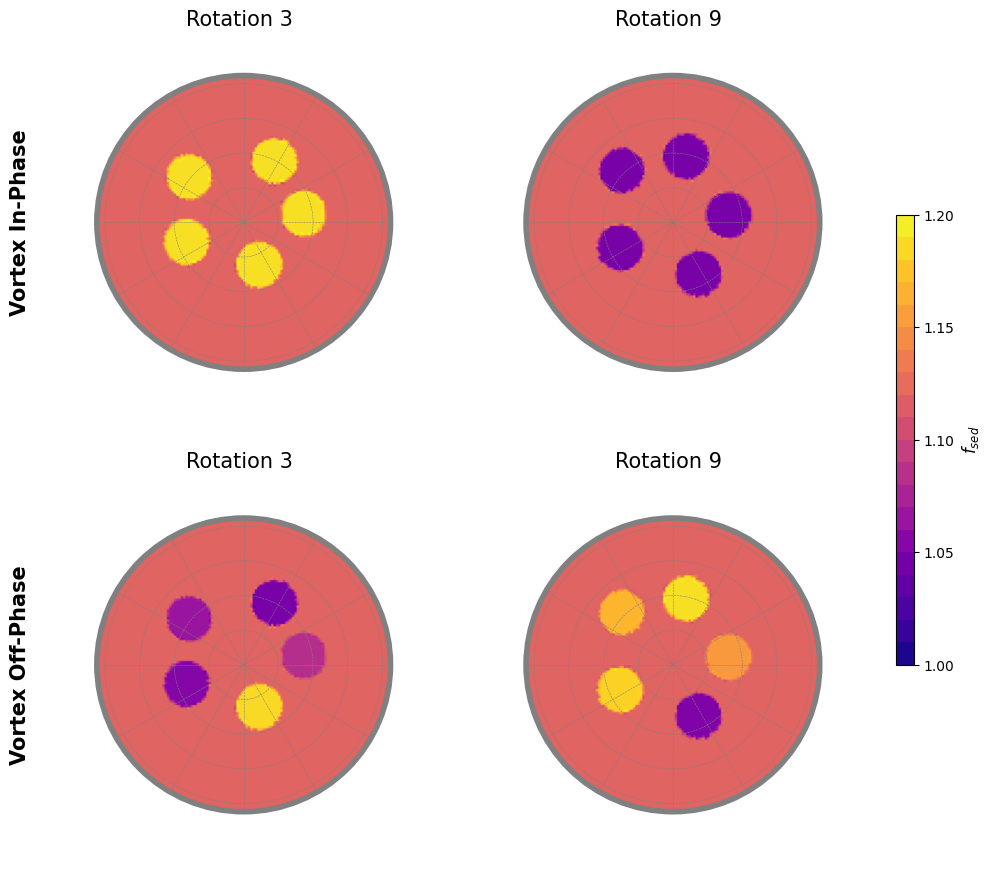

In [66]:
save = True
# save = False

### test onlyVortex static/dynamic

fig, axs = plt.subplots(2,2, figsize=(9,9), sharex=True, sharey=True)
c1, c2 = 3, 9 # no of rotations 
t1, t2 = 10*c1, 10*c2

im1, im2, im3, im4 = None, None, None, None
im1, im2 = phot_vs['0']['gray_array'][t1], phot_vs['0']['gray_array'][t2]
im3, im4 = phot_vd2['0']['gray_array'][t1], phot_vd2['0']['gray_array'][t2]

### First row: type `VS`

for i, im in enumerate([im1, im2, im3, im4]):
    # cut out a circle in the center of the image with radius ysize/2
    implot = im.copy()

    ysize, xsize = implot.shape
    y, x = np.ogrid[:ysize, :xsize]
    center = (ysize / 2, xsize / 2)
    radius = 64 # pixels
    mask = (y - center[0])**2 + (x - center[1])**2 > radius**2

    implot[mask] = np.nan  # Set pixels outside the circle to NaN
    
    ax = axs[i//2, i%2]
    ax.set_aspect('equal')
    ax.imshow(implot, cmap='plasma', vmin=95, vmax=150)
    ax.set_ylim(ysize/5, 4*ysize/5)
    ax.set_xlim (xsize/5, 4*xsize/5)
    
    ax.set_xticks([]), ax.set_yticks([])
    for spines in ax.spines.values():
        spines.set_visible(False)

    # plot polar grid
    r_outer = radius
    # Draw polar coordinate grid (circles)
    for r_grid in np.arange(0, r_outer, 15):
        circle = Circle((xsize / 2, ysize / 2), r_grid, fill=False, edgecolor='gray', linestyle='--', linewidth=0.4, alpha=1)
        ax.add_patch(circle)

    ax.add_patch(Circle((xsize / 2, ysize / 2), r_grid+3.5, fill=False, edgecolor='gray', linestyle='-', linewidth=4, alpha=1))

    # Add radial lines for polar grid
    for lon in np.arange(0, 360, 30):
        theta_rad = np.radians(lon)
        x_line = xsize / 2 + r_outer * np.sin(theta_rad)
        y_line = ysize / 2 - r_outer * np.cos(theta_rad)
        ax.plot([xsize / 2, x_line], [ysize / 2, y_line], 'gray', ls='--', alpha=1, linewidth=0.4)
    
    ax.text(125, 235, f'Rotation {c1 if i%2==0 else c2}', fontsize=15)
    if i==0: ax.set_ylabel('Vortex In-Phase', fontsize=15, weight='bold')
    if i==2: ax.set_ylabel('Vortex Off-Phase', fontsize=15, weight='bold')

## add a vertical colorbar
cbar_ax = fig.add_axes([1.0, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
bounds = np.linspace(1.0, 1.2, num=21)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=1.0, vmax=1.2))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, boundaries=bounds, ticks=bounds)
cbar.set_label(r'$f_{sed}$', fontsize=12)
cbar.ax.set_yticks(np.linspace(1.0, 1.2, num=5))
cbar.ax.set_yticklabels([f'{x:.2f}' for x in np.linspace(1.0, 1.2, num=5)], fontsize=10)

    
plt.tight_layout()
if save:
    handle = f'vortex_inphase_offphase_comparison.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.show()
plt.close(fig)


/var/folders/n_/ynkgs9fs2ts72fkcb79xcjlh0000gn/T/ipykernel_5412/3993605921.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


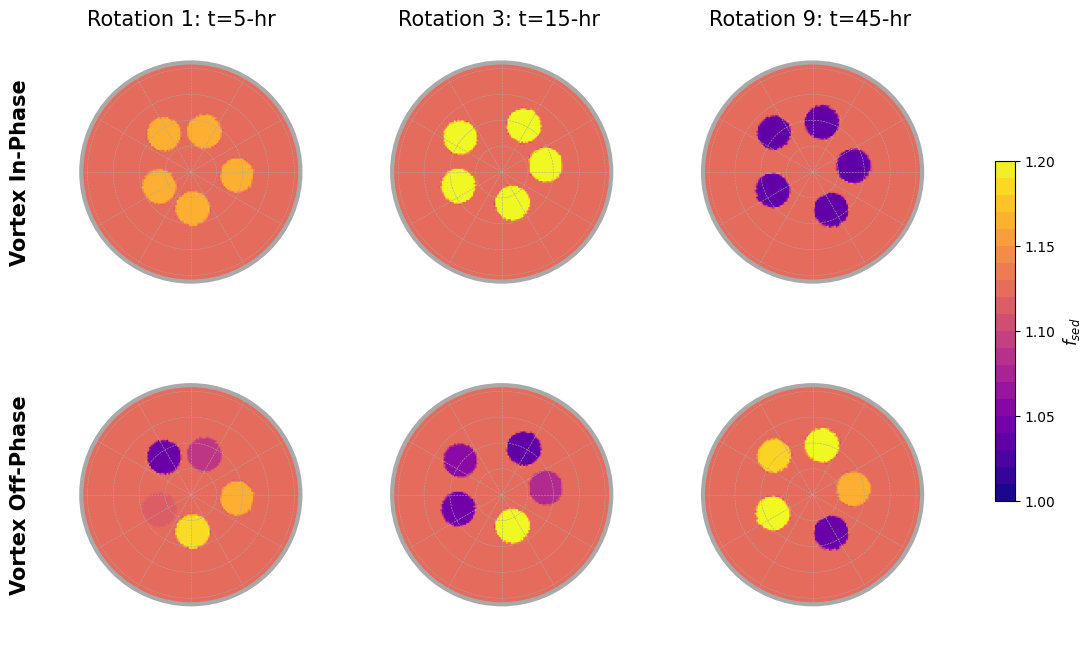

In [96]:
save = True
# save = False

### test onlyVortex static/dynamic

fig, axs = plt.subplots(2, 3, figsize=(10, 6.8), sharex=True, sharey=True)
c1, c2, c3 = 1, 3, 9 # no of rotations 
tlist = [c1, c2, c3]
t1, t2, t3 = 10*c1, 10*c2, 10*c3

im1, im2, im3, im4, im5, im6 = None, None, None, None, None, None
im1, im2, im3 = [phot_vs['0']['gray_array'][t1], 
                phot_vs['0']['gray_array'][t2], 
                phot_vs['0']['gray_array'][t3]]

im4, im5, im6 = [phot_vd2['0']['gray_array'][t1], 
                phot_vd2['0']['gray_array'][t2],
                phot_vd2['0']['gray_array'][t3]]

### First row: type `VS`

for i, im in enumerate([im1, im2, im3, im4, im5, im6]):
    # cut out a circle in the center of the image with radius ysize/2
    implot = im.copy()

    ysize, xsize = implot.shape
    y, x = np.ogrid[:ysize, :xsize]
    center = (ysize / 2, xsize / 2)
    radius = 64 # pixels
    mask = (y - center[0])**2 + (x - center[1])**2 > radius**2

    implot[mask] = np.nan  # Set pixels outside the circle to NaN
    
    ax = axs[i//3, i%3]
    # ax.set_aspect('equal')
    ax.imshow(implot, cmap='plasma', vmin=100, vmax=145)
    ax.set_ylim(ysize/5, 4*ysize/5)
    ax.set_xlim (xsize/5, 4*xsize/5)
    
    ax.set_xticks([]), ax.set_yticks([])

    for spines in ax.spines.values():
        spines.set_visible(False)

    # plot polar grid
    r_outer = radius
    # Draw polar coordinate grid (circles)
    for r_grid in np.arange(0, r_outer, 15):
        circle = Circle((xsize / 2, ysize / 2), r_grid, fill=False, edgecolor='darkgray', linestyle='--', linewidth=0.4, alpha=1)
        ax.add_patch(circle)

    ax.add_patch(Circle((xsize / 2, ysize / 2), r_grid+3.5, fill=False, edgecolor='darkgray', linestyle='-', linewidth=3, alpha=1))

    # Add radial lines for polar grid
    for lon in np.arange(0, 360, 30):
        theta_rad = np.radians(lon)
        x_line = xsize / 2 + r_outer * np.sin(theta_rad)
        y_line = ysize / 2 - r_outer * np.cos(theta_rad)
        ax.plot([xsize / 2, x_line], [ysize / 2, y_line], 'darkgray', ls='--', alpha=1, linewidth=0.4)
    
    if i<3: ax.text(90, 235, f'Rotation {tlist[i%3]}: t={tlist[i%3]*5}-hr', fontsize=15)
    if i==0: ax.set_ylabel('Vortex In-Phase', fontsize=15, weight='bold')
    if i==3: ax.set_ylabel('Vortex Off-Phase', fontsize=15, weight='bold')

## add a vertical colorbar
cbar_ax = fig.add_axes([1.0, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
bounds = np.linspace(1.0, 1.2, num=21)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=1.0, vmax=1.2))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, boundaries=bounds, ticks=bounds)
cbar.set_label(r'$f_{sed}$', fontsize=12)
cbar.ax.set_yticks(np.linspace(1.0, 1.2, num=5))
cbar.ax.set_yticklabels([f'{x:.2f}' for x in np.linspace(1.0, 1.2, num=5)], fontsize=10)
    
plt.tight_layout()
plt.subplots_adjust(wspace=0.001, hspace=0.0001)

if save:
    handle = f'vortex_inphase_offphase_comparison_B.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.show()
plt.close(fig)


### Figure: Plot different light curves for different band configurations.

In [8]:
### Different band configurations

# 60 hours baseline, static pole: Test Static (ts), v0 is phot_ts
# v1
photrunName_ts1 = 'test_polar_v1_static.h5'
phot_ts1, specs_ts1, codecs_ts1, codec_loaded_ts1 = read_spec_codecs(photrunName_ts1) 
time_ts1 = phot_ts1['0']['time_array'] # load the time indices 

# v2
photrunName_ts2 = 'test_polar_v2_static.h5'
phot_ts2, specs_ts2, codecs_ts2, codec_loaded_ts2 = read_spec_codecs(photrunName_ts2) 
time_ts2 = phot_ts2['0']['time_array'] # load the time indices 

Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v1_static_1200k_clouds=20/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20
Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v2_static_1200k_clouds=20/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20


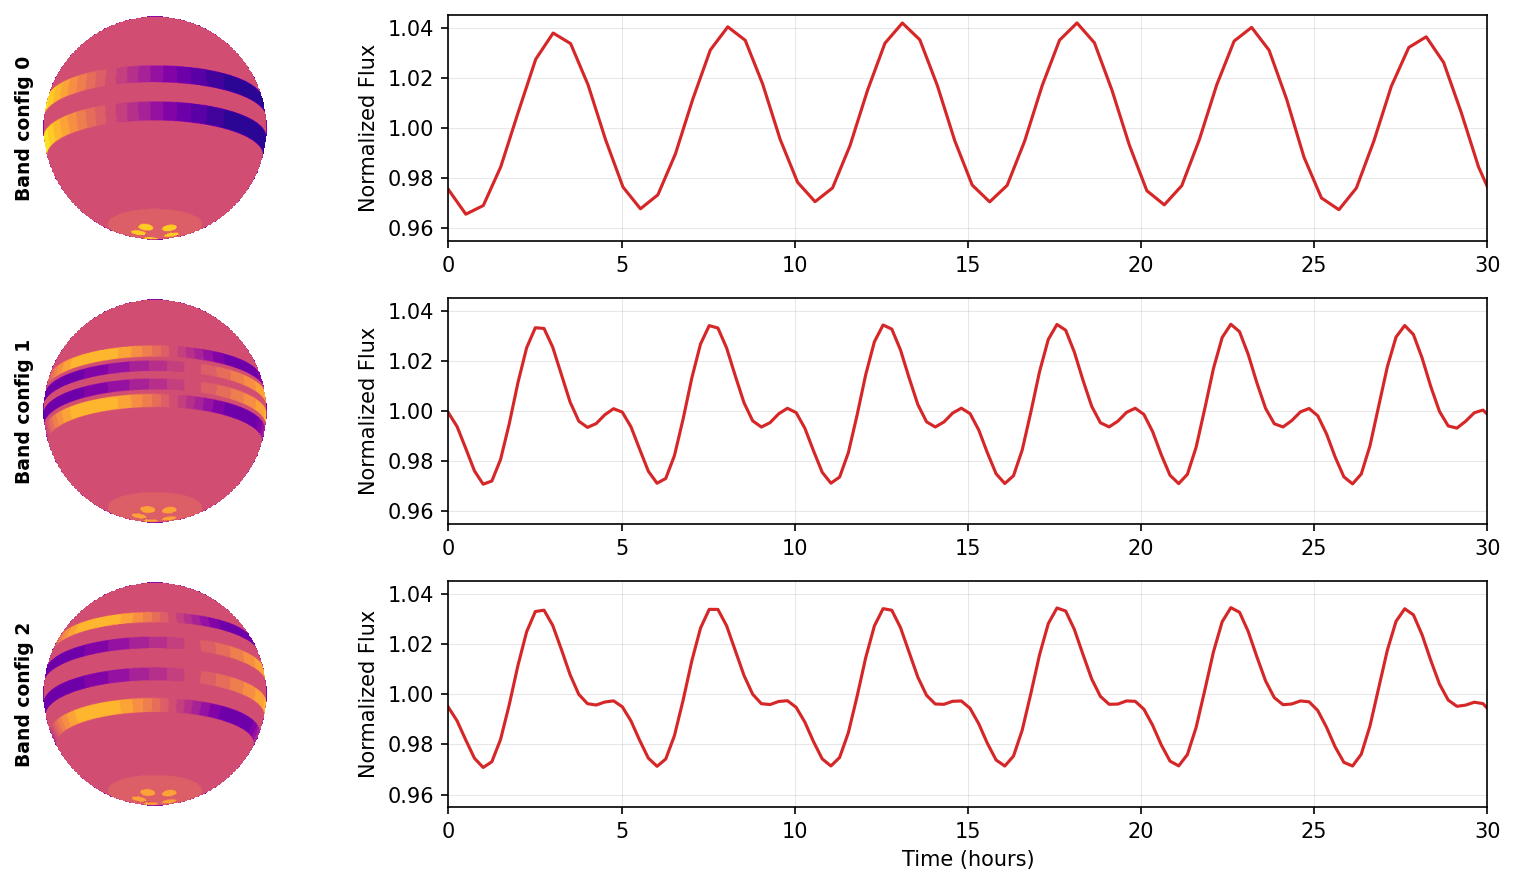

In [104]:
save = True
# save = False

fig, axs = plt.subplots(3,2, figsize=(11,6), dpi=150, width_ratios=(1,2))
inclin = '70'
t_idx = 18
wmin, wmax = 1.3, 1.4
looper = [[codecs_ts, specs_ts], 
          [codecs_ts1, specs_ts1], 
          [codecs_ts2, specs_ts2]]

for i, array in enumerate(looper):
    codec, spec = array
    ax = axs[i,0]
    t = t_idx if i>0 else t_idx - 5
    ax.imshow(codec[inclin][t]['composite'], cmap='plasma')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_ylabel(f'Band config {i}', weight='bold', fontsize=9)

    ax = axs[i,1]
    # plot light curve at 1.3um
    fluxes = calculate_wavebin_flux(spec[inclin], wmin, wmax)
    # normalize light curves
    fluxes = (fluxes-np.mean(fluxes))/np.max(fluxes) +1
    timeplot = time_ts1 if i>0 else time_ts
    ax.plot(timeplot, fluxes, c='tab:red')
    ax.set_xlim(0, 30)
    ax.set_ylim(0.955, 1.045)
    ax.set_ylabel('Normalized Flux', fontsize=10)
    ax.grid(True, lw=0.5, alpha=0.3)
    if i==2: ax.set_xlabel('Time (hours)', fontsize=10)

plt.tight_layout()

if save:
    handle = f'different_band_config_lightcurves.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=500, bbox_inches='tight')

plt.show()
plt.close(fig)

        